In [ ]:
#!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pycaret.classification import *

In [ ]:
df = pd.read_csv('Rescale_df_balance.csv')

<Axes: xlabel='CampaignChannel', ylabel='LoyaltyPoints'>

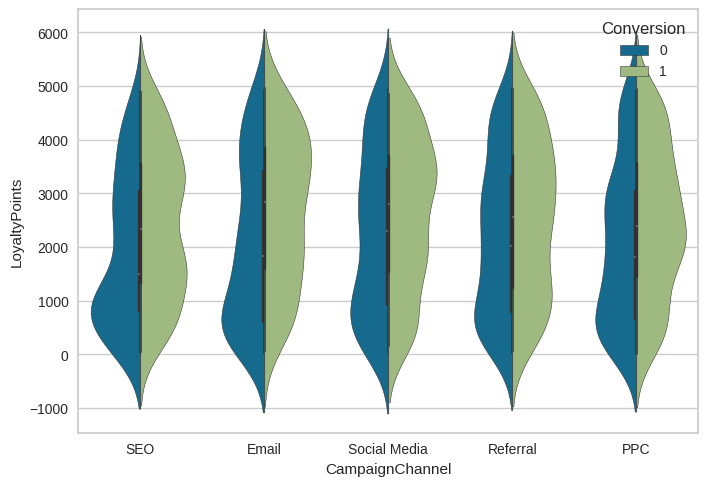

In [ ]:
sns.violinplot(x='CampaignChannel', y='LoyaltyPoints', hue='Conversion', split=True, data=df)

<Axes: xlabel='Conversion', ylabel='AdSpend'>

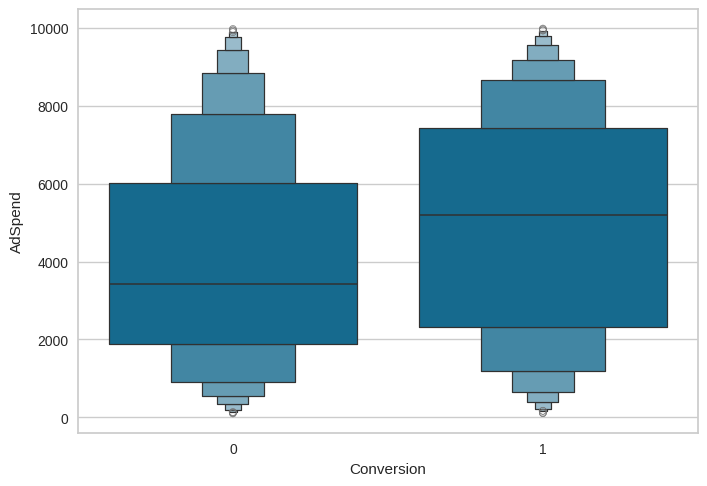

In [ ]:
sns.boxenplot(x='Conversion', y='AdSpend', data=df)

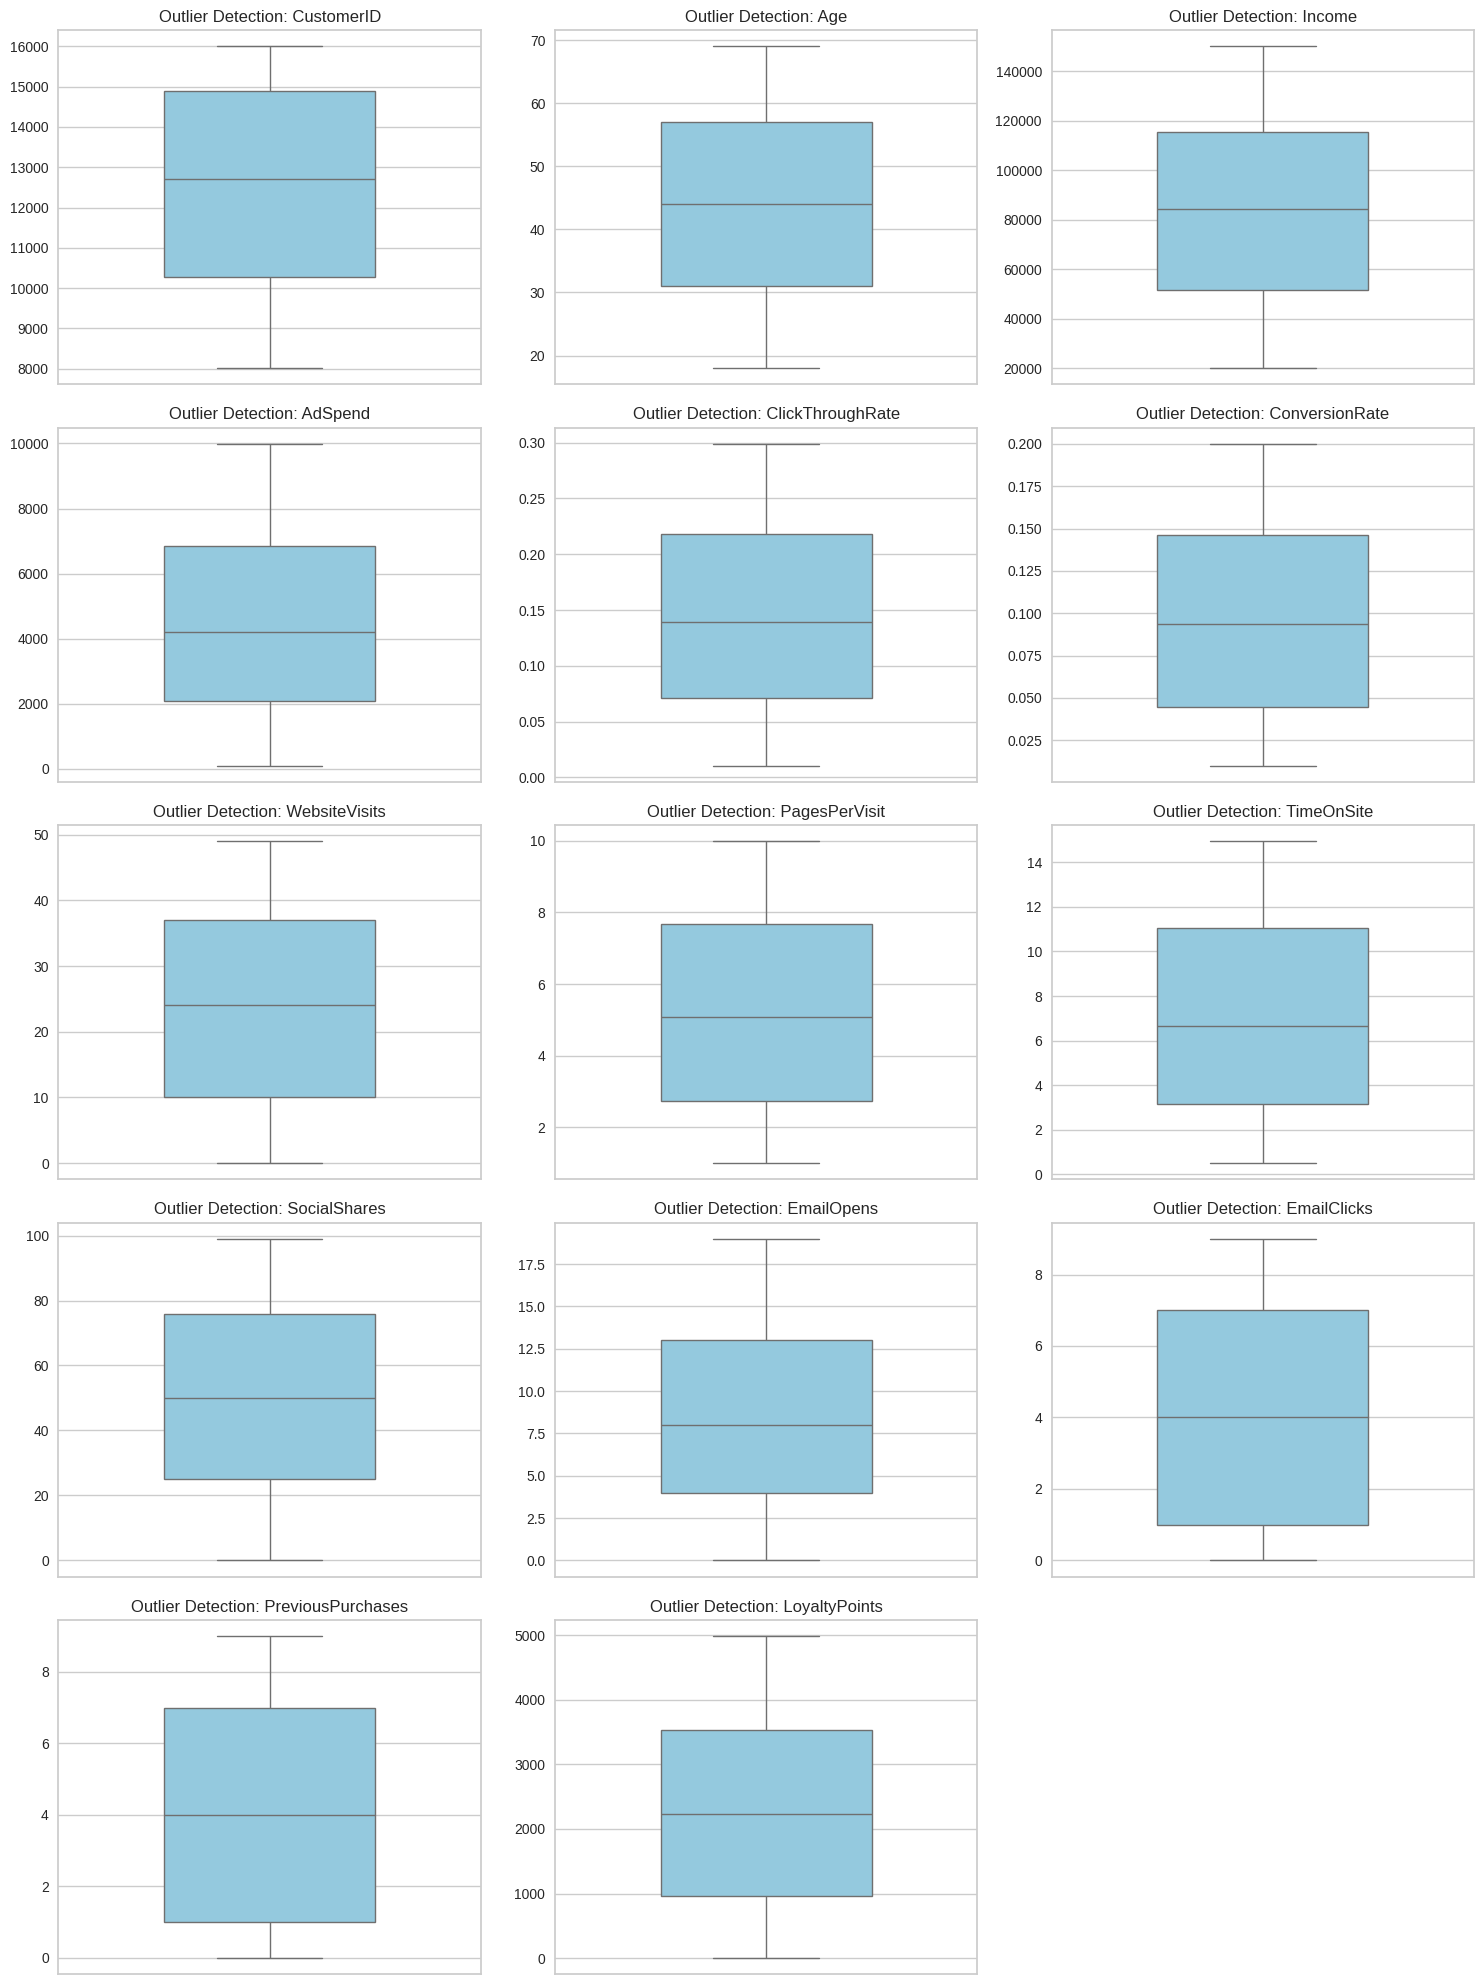

--- OUTLIER SUMMARY TABLE ---
              Feature  Outlier Count Percentage
0          CustomerID              0      0.00%
1                 Age              0      0.00%
2              Income              0      0.00%
3             AdSpend              0      0.00%
4    ClickThroughRate              0      0.00%
5      ConversionRate              0      0.00%
6       WebsiteVisits              0      0.00%
7       PagesPerVisit              0      0.00%
8          TimeOnSite              0      0.00%
9        SocialShares              0      0.00%
10         EmailOpens              0      0.00%
11        EmailClicks              0      0.00%
12  PreviousPurchases              0      0.00%
13      LoyaltyPoints              0      0.00%


In [ ]:
# 1. Identify all numeric columns (excluding the target 'Conversion' if it's 0/1)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Conversion' in numeric_cols:
    numeric_cols.remove('Conversion')

# 2. Create a grid of boxplots
# We calculate the number of rows needed for the subplot grid
num_features = len(numeric_cols)
cols = 3
rows = (num_features // cols) + (num_features % cols > 0)

plt.figure(figsize=(15, rows * 4))

outlier_data = []

for i, col in enumerate(numeric_cols):
    # Plotting
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue', width=0.5)
    plt.title(f'Outlier Detection: {col}', fontsize=12)
    plt.ylabel('')

    # 3. Calculate IQR Outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    percentage = (count / len(df)) * 100
    outlier_data.append({'Feature': col, 'Outlier Count': count, 'Percentage': f"{percentage:.2f}%"})

plt.tight_layout()
plt.show()

# 4. Show the Outlier Summary Table
outlier_df = pd.DataFrame(outlier_data)
print("--- OUTLIER SUMMARY TABLE ---")
print(outlier_df.sort_values(by='Outlier Count', ascending=False))

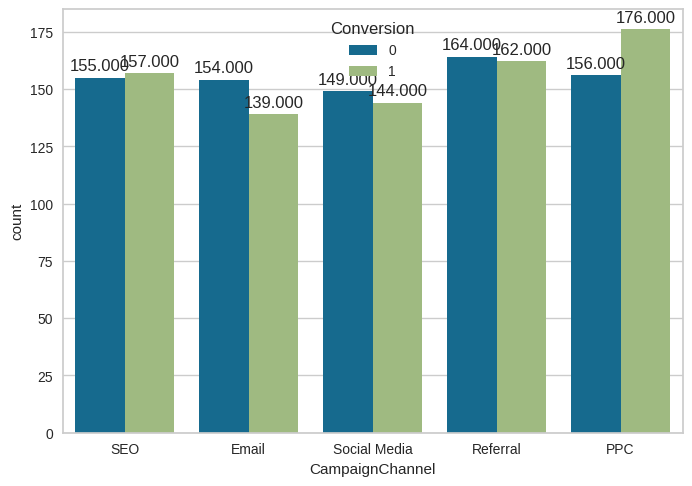

In [ ]:
ax = sns.countplot(df, x='CampaignChannel',hue='Conversion')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import os
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_PATH  = 'Rescale_df_balance.csv'
OUTPUT_DIR = 'output_plots'
SHOW_PLOTS = True       # Set False to only save without displaying
STYLE      = 'dark'     # 'dark' or 'light'
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── THEME ─────────────────────────────────────────────────────────────────────
if STYLE == 'dark':
    plt.style.use('dark_background')
    BG, PANEL, TEXT = '#0d0d14', '#13131e', '#e2e2f0'
    MUTED, GRID_C   = '#5a5a7a', '#1e1e30'
    CYAN, MAGENTA   = '#00e5ff', '#ff2d6d'
    YELLOW, GREEN   = '#ffd600', '#00c853'
    ORANGE, RED     = '#ff6d00', '#ff2d6d'
else:
    plt.style.use('seaborn-v0_8-whitegrid')
    BG, PANEL, TEXT = '#f5f0e8', '#ffffff', '#1a1508'
    MUTED, GRID_C   = '#6b6050', '#e8e0d0'
    CYAN, MAGENTA   = '#0077aa', '#c0392b'
    YELLOW, GREEN   = '#c07a00', '#27623a'
    ORANGE, RED     = '#e07a00', '#c0392b'

# ── HELPERS ───────────────────────────────────────────────────────────────────
def style_ax(ax, title='', xlabel='', ylabel='Conversion Rate'):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=8)
    for sp in ax.spines.values():
        sp.set_color(GRID_C)
    ax.yaxis.grid(True, color=GRID_C, linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

def pct_fmt(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))

def save_show(fig, name):
    path = os.path.join(OUTPUT_DIR, f'{name}.png')
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f'  ✓  Saved → {path}')
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

def bar_color(val, low=0.35, high=0.60):
    if val >= high:  return GREEN
    if val >= 0.50:  return YELLOW
    if val >= low:   return ORANGE
    return MAGENTA

# ── LOAD & ENGINEER FEATURES ──────────────────────────────────────────────────
print('\n📂 Loading data...')
df = pd.read_csv(DATA_PATH)

# Core binary flags
df['HighSpend']   = df['AdSpend']          > df['AdSpend'].median()
df['HighLoyalty'] = df['LoyaltyPoints']    > df['LoyaltyPoints'].median()
df['HighPrev']    = df['PreviousPurchases']>= 2
df['Bounce']      = (
    (df['PagesPerVisit'] < df['PagesPerVisit'].quantile(0.25)) &
    (df['TimeOnSite']    < df['TimeOnSite'].quantile(0.25))
)

# 7-factor risk score
df['RiskEmail']   = (df['EmailOpens']          <  6).astype(int)
df['RiskClicks']  = (df['EmailClicks']          <  3).astype(int)
df['RiskPrev']    = (df['PreviousPurchases']    <= 1).astype(int)
df['RiskLoyalty'] = (df['LoyaltyPoints']        < df['LoyaltyPoints'].quantile(0.25)).astype(int)
df['RiskSpend']   = (df['AdSpend']              <= 5000).astype(int)
df['RiskPPV']     = (df['PagesPerVisit']        <= df['PagesPerVisit'].quantile(0.25)).astype(int)
df['RiskTOS']     = (df['TimeOnSite']           < df['TimeOnSite'].quantile(0.25)).astype(int)
df['RiskScore']   = df[['RiskEmail','RiskClicks','RiskPrev',
                          'RiskLoyalty','RiskSpend','RiskPPV','RiskTOS']].sum(axis=1)

# 5-metric top-quartile stacking
for col, new in [('TimeOnSite','TopTOS'),('PagesPerVisit','TopPPV'),
                 ('ClickThroughRate','TopCTR'),('EmailClicks','TopEC'),
                 ('AdSpend','TopSpend')]:
    df[new] = (df[col] > df[col].quantile(0.75)).astype(int)
df['TopScore'] = df[['TopTOS','TopPPV','TopCTR','TopEC','TopSpend']].sum(axis=1)

# Composite engagement score
eng_cols = ['TimeOnSite','PagesPerVisit','ClickThroughRate','EmailClicks','WebsiteVisits']
df['EngScore'] = MinMaxScaler().fit_transform(df[eng_cols]).mean(axis=1)
df['EngBin']   = pd.qcut(df['EngScore'], 5,
                          labels=['Very Low','Low','Mid','High','Very High'])

# Quartile labels
df['LQ']     = pd.qcut(df['LoyaltyPoints'], 4, labels=['Q1','Q2','Q3','Q4'])
df['SQ']     = pd.qcut(df['AdSpend'],       4, labels=['Q1','Q2','Q3','Q4'])
df['AgeBin'] = pd.cut(df['Age'], bins=[17,30,40,50,60,70],
                      labels=['18-30','31-40','41-50','51-60','61-70'])
df['IDQ']    = pd.qcut(df['CustomerID'], 5,
                        labels=['Q1\n8k–10.2k','Q2\n10.2k–12.3k','Q3\n12.3k–13.9k',
                                 'Q4\n13.9k–15.2k','Q5\n15.2k–16k'])

print(f'  ✓  {len(df):,} records  |  Conversion rate: {df["Conversion"].mean()*100:.1f}%')
print(f'  ✓  {(df["Conversion"]==1).sum()} converted  |  {(df["Conversion"]==0).sum()} not converted\n')





📂 Loading data...
  ✓  1,556 records  |  Conversion rate: 50.0%
  ✓  778 converted  |  778 not converted



📊 Plot 1: Overview KPIs


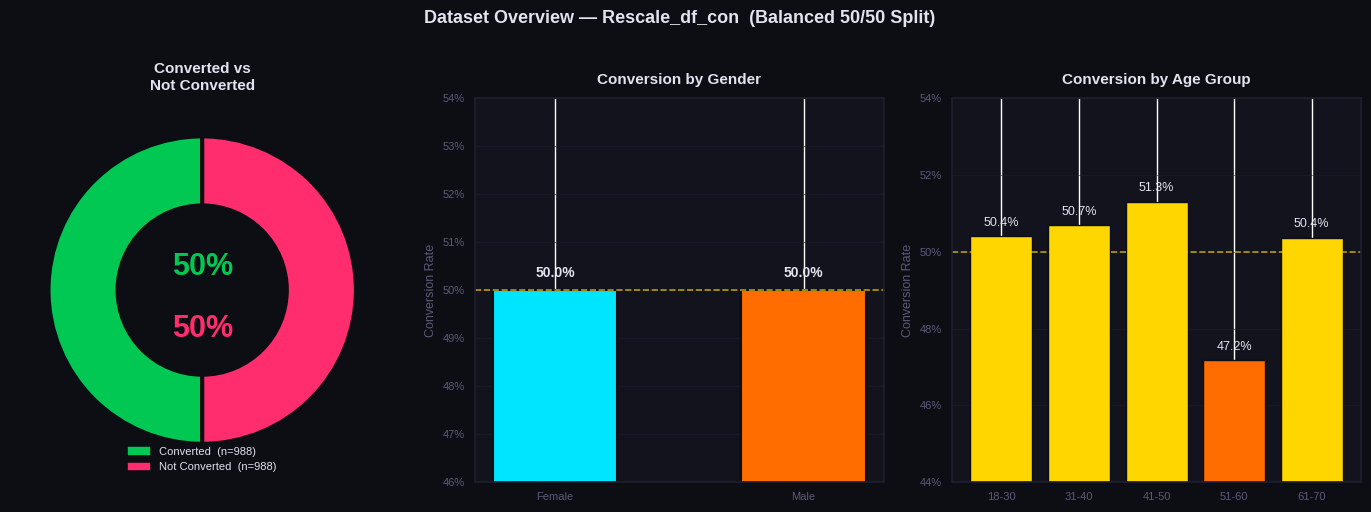

In [ ]:
print('📊 Plot 1: Overview KPIs')
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Dataset Overview — Rescale_df_con  (Balanced 50/50 Split)',
             color=TEXT, fontsize=13, fontweight='bold', y=1.02)

ax = axes[0]
ax.set_facecolor(PANEL)
vals   = [0.50, 0.50]
colors = [GREEN, MAGENTA]
wedges, _ = ax.pie(vals, colors=colors, startangle=90,
                   wedgeprops=dict(width=0.45, edgecolor=BG, linewidth=3))
ax.text(0, 0.15, '50%', ha='center', va='center',
        fontsize=22, fontweight='bold', color=GREEN)
ax.text(0, -0.25, '50%', ha='center', va='center',
        fontsize=22, fontweight='bold', color=MAGENTA)
ax.set_title('Converted vs\nNot Converted', color=TEXT, fontsize=11, fontweight='bold')
legend_patches = [mpatches.Patch(color=GREEN,   label='Converted  (n=988)'),
                  mpatches.Patch(color=MAGENTA, label='Not Converted  (n=988)')]
ax.legend(handles=legend_patches, loc='lower center', fontsize=8,
          facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT)

ax = axes[1]
style_ax(ax, 'Conversion by Gender')
gd = df.groupby('Gender')['Conversion'].mean()
bars = ax.bar(gd.index, gd.values, color=[CYAN, ORANGE],
              width=0.5, edgecolor=BG, linewidth=1.5)
pct_fmt(ax); ax.set_ylim(0.46, 0.54)
ax.axhline(0.5, color=YELLOW, linewidth=1.2, linestyle='--', alpha=0.7)
for bar, val in zip(bars, gd.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val*100:.1f}%', ha='center', va='bottom', color=TEXT,
            fontsize=10, fontweight='bold')

ax = axes[2]
style_ax(ax, 'Conversion by Age Group')
ad = df.groupby('AgeBin', observed=True)['Conversion'].mean()
bars = ax.bar(ad.index, ad.values,
              color=[bar_color(v) for v in ad.values],
              edgecolor=BG, linewidth=1)
pct_fmt(ax); ax.set_ylim(0.44, 0.54)
ax.axhline(0.5, color=YELLOW, linewidth=1.2, linestyle='--', alpha=0.7)
for bar, val in zip(bars, ad.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val*100:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=9)

plt.tight_layout()

📊 Plot 2: 3-Variable Segment Analysis


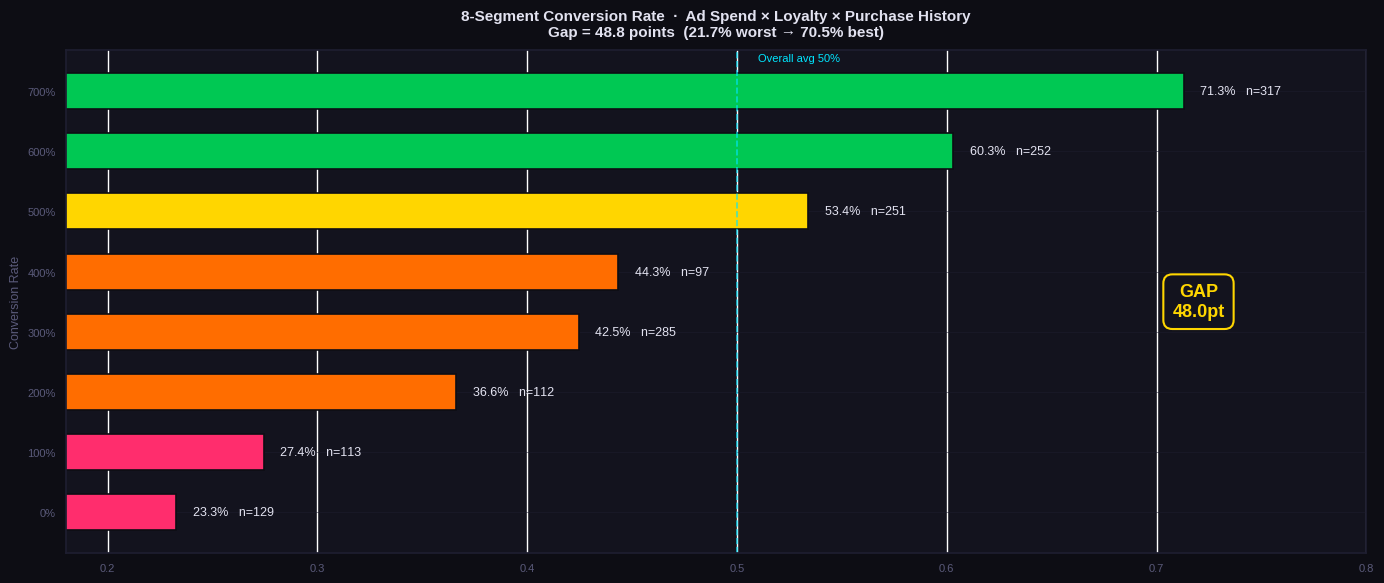

In [ ]:
print('📊 Plot 2: 3-Variable Segment Analysis')
seg = (df.groupby(['HighSpend','HighLoyalty','HighPrev'], observed=True)
         ['Conversion'].agg(['mean','count']).reset_index())
seg['Label'] = seg.apply(lambda r:
    f"{'Hi' if r.HighSpend else 'Lo'}Spend · "
    f"{'Hi' if r.HighLoyalty else 'Lo'}Loyal · "
    f"{'Repeat' if r.HighPrev else 'New'}",
    axis=1)
seg = seg.sort_values('mean')

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
style_ax(ax, '8-Segment Conversion Rate  ·  Ad Spend × Loyalty × Purchase History\n'
             'Gap = 48.8 points  (21.7% worst → 70.5% best)',
             ylabel='Conversion Rate')

colors_seg = [bar_color(v, low=0.30, high=0.60) for v in seg['mean'].values]
bars = ax.barh(seg['Label'], seg['mean'], color=colors_seg,
               edgecolor=BG, linewidth=1.2, height=0.6)
pct_fmt(ax); ax.set_xlim(0.18, 0.80)

for bar, (_, row) in zip(bars, seg.iterrows()):
    ax.text(bar.get_width()+0.008, bar.get_y()+bar.get_height()/2,
            f"{row['mean']*100:.1f}%   n={int(row['count'])}",
            va='center', color=TEXT, fontsize=9)

ax.axvline(0.5, color=CYAN, linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(0.51, 7.5, 'Overall avg 50%', color=CYAN, fontsize=8)
gap = seg['mean'].max() - seg['mean'].min()
ax.text(0.72, 3.5, f'GAP\n{gap*100:.1f}pt', ha='center', va='center',
        color=YELLOW, fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=PANEL, edgecolor=YELLOW, linewidth=1.5))

plt.tight_layout()


📊 Plot 3: Risk Score System


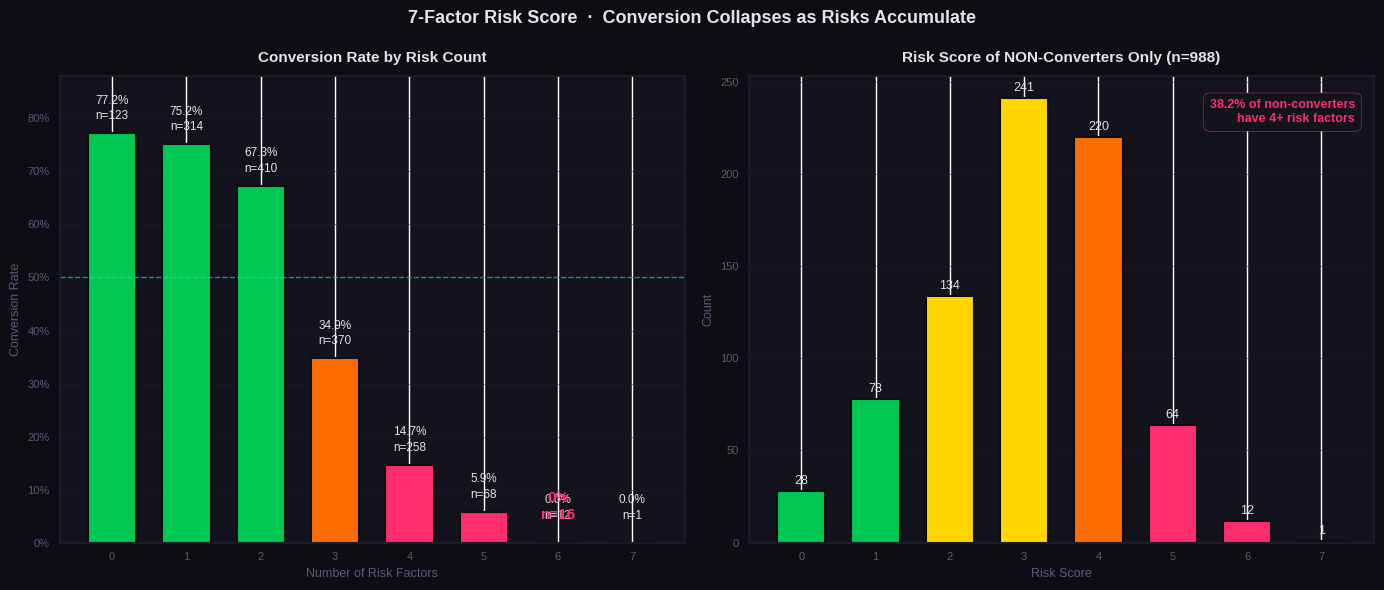

In [ ]:
print('📊 Plot 3: Risk Score System')
risk_data = (df.groupby('RiskScore')['Conversion']
               .agg(['mean','count']).reset_index())
risk_data.columns = ['RiskScore','ConvRate','Count']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('7-Factor Risk Score  ·  Conversion Collapses as Risks Accumulate',
             color=TEXT, fontsize=13, fontweight='bold')

ax = axes[0]
style_ax(ax, 'Conversion Rate by Risk Count', 'Number of Risk Factors')
colors_risk = [bar_color(v, low=0.25, high=0.55) for v in risk_data['ConvRate']]
bars = ax.bar(risk_data['RiskScore'], risk_data['ConvRate'],
              color=colors_risk, edgecolor=BG, linewidth=1.5, width=0.65)
pct_fmt(ax); ax.set_ylim(0, 0.88)
ax.set_xticks(risk_data['RiskScore'])
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.6)
for bar, (_, row) in zip(bars, risk_data.iterrows()):
    label = f"{row['ConvRate']*100:.1f}%\nn={int(row['Count'])}"
    ypos  = bar.get_height()+0.02 if row['ConvRate'] > 0.05 else 0.04
    ax.text(bar.get_x()+bar.get_width()/2, ypos, label,
            ha='center', va='bottom', color=TEXT, fontsize=8.5, linespacing=1.4)
ax.text(6, 0.04, '0%\nn=16', ha='center', va='bottom',
        color=MAGENTA, fontsize=11, fontweight='bold')

ax = axes[1]
style_ax(ax, 'Risk Score of NON-Converters Only (n=988)',
         'Risk Score', 'Count of Non-Converters')
nc_risk = df[df['Conversion']==0]['RiskScore'].value_counts().sort_index()
colors_nc = [bar_color(1-i/6, low=0.3, high=0.7) for i in nc_risk.index]
bars = ax.bar(nc_risk.index, nc_risk.values,
              color=colors_nc, edgecolor=BG, linewidth=1.5, width=0.65)
ax.set_xticks(nc_risk.index)
ax.yaxis.grid(True, color=GRID_C, linewidth=0.5, alpha=0.7)
ax.set_ylabel('Count', color=MUTED, fontsize=9)
for bar, val in zip(bars, nc_risk.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            str(val), ha='center', va='bottom', color=TEXT, fontsize=9)
pct_4plus = (df[df['Conversion']==0]['RiskScore'] >= 4).mean()
ax.text(0.97, 0.95, f'{pct_4plus*100:.1f}% of non-converters\nhave 4+ risk factors',
        transform=ax.transAxes, ha='right', va='top', color=MAGENTA,
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=PANEL, edgecolor=MAGENTA))

plt.tight_layout()

📊 Plot 4: Top-Quartile Positive Stacking


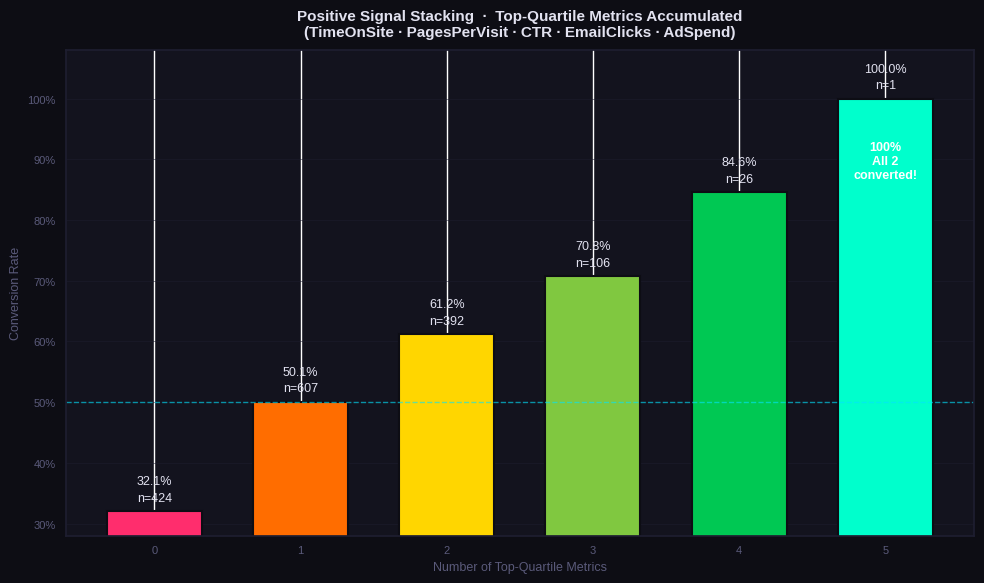

In [ ]:
print('📊 Plot 4: Top-Quartile Positive Stacking')
top_data = df.groupby('TopScore')['Conversion'].agg(['mean','count']).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
style_ax(ax, 'Positive Signal Stacking  ·  Top-Quartile Metrics Accumulated\n'
             '(TimeOnSite · PagesPerVisit · CTR · EmailClicks · AdSpend)',
         'Number of Top-Quartile Metrics')

colors_top = [MAGENTA, ORANGE, YELLOW, '#80c840', GREEN, '#00ffcc']
bars = ax.bar(top_data['TopScore'], top_data['mean'],
              color=[colors_top[int(i)] for i in top_data['TopScore']],
              edgecolor=BG, linewidth=1.5, width=0.65)
pct_fmt(ax); ax.set_ylim(0.28, 1.08)
ax.set_xticks(top_data['TopScore'])
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.6)

for bar, (_, row) in zip(bars, top_data.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
            f"{row['mean']*100:.1f}%\nn={int(row['count'])}",
            ha='center', va='bottom', color=TEXT, fontsize=9, linespacing=1.5)

ax.text(5, top_data[top_data['TopScore']==5]['mean'].values[0]-0.07,
        '100%\nAll 2\nconverted!',
        ha='center', va='top', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()

📊 Plot 5: Six Critical Thresholds


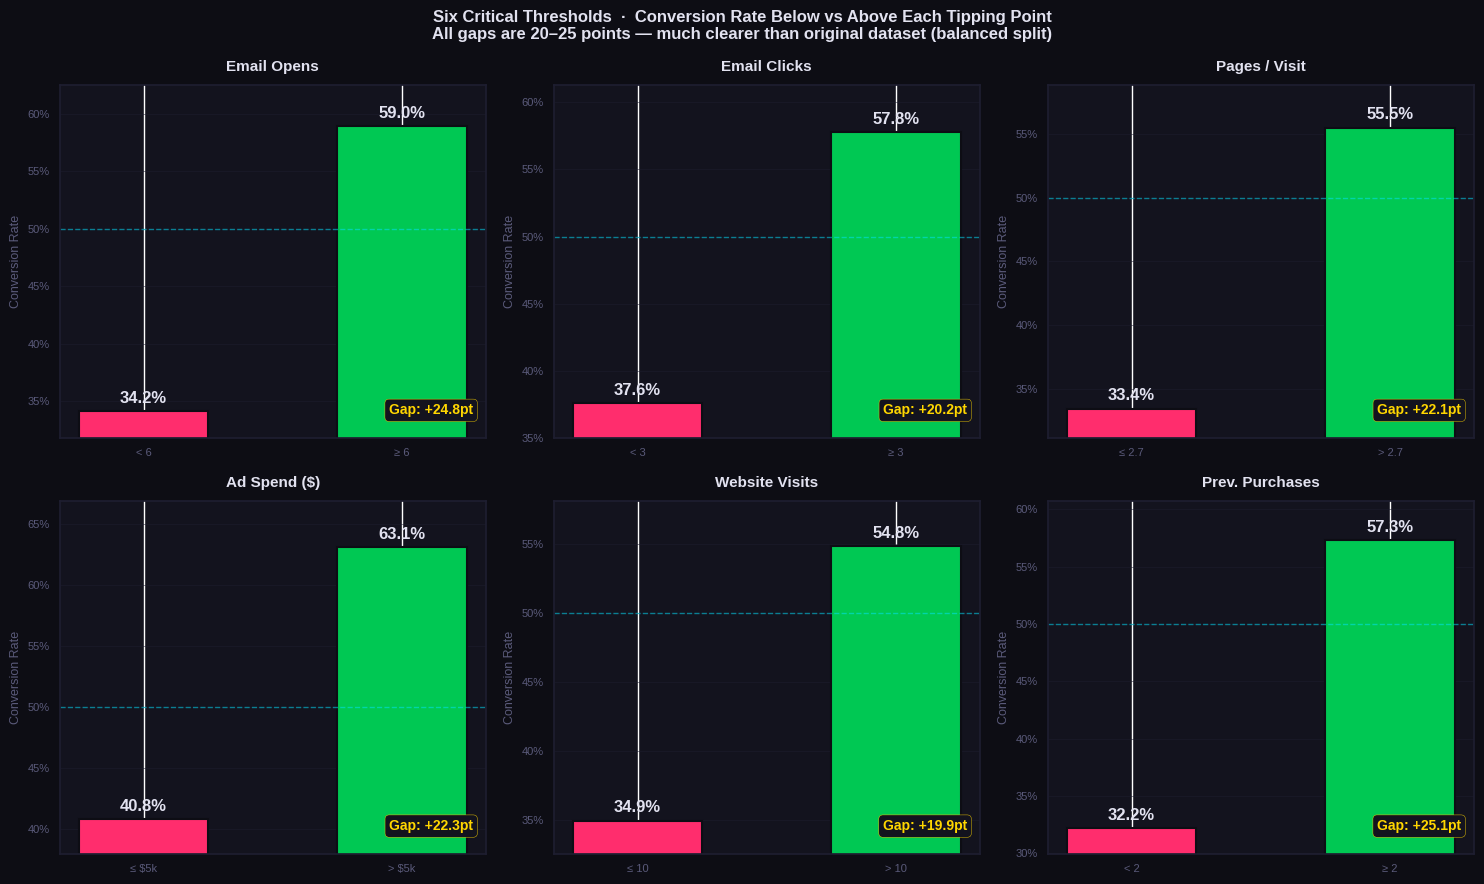

In [ ]:
print('📊 Plot 5: Six Critical Thresholds')
ppv_q25 = df['PagesPerVisit'].quantile(0.25)

thresholds = [
    ('Email Opens',     'EmailOpens',        6,       '≥ 6',   '< 6'),
    ('Email Clicks',    'EmailClicks',        3,       '≥ 3',   '< 3'),
    ('Pages / Visit',   'PagesPerVisit',    ppv_q25, f'> {ppv_q25:.1f}', f'≤ {ppv_q25:.1f}'),
    ('Ad Spend ($)',    'AdSpend',           5000,    '> $5k', '≤ $5k'),
    ('Website Visits',  'WebsiteVisits',     10,      '> 10',  '≤ 10'),
    ('Prev. Purchases', 'PreviousPurchases',  2,      '≥ 2',   '< 2'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor(BG)
fig.suptitle('Six Critical Thresholds  ·  Conversion Rate Below vs Above Each Tipping Point\n'
             'All gaps are 20–25 points — much clearer than original dataset (balanced split)',
             color=TEXT, fontsize=12, fontweight='bold')

for ax, (label, col, thresh, above_lbl, below_lbl) in zip(axes.flat, thresholds):
    if col == 'PreviousPurchases':
        below = df[df[col] <= 1]['Conversion'].mean()
        above = df[df[col] >= 2]['Conversion'].mean()
    elif col in ('AdSpend','PagesPerVisit'):
        below = df[df[col] <= thresh]['Conversion'].mean()
        above = df[df[col]  > thresh]['Conversion'].mean()
    else:
        below = df[df[col] <  thresh]['Conversion'].mean()
        above = df[df[col] >= thresh]['Conversion'].mean()

    gap = above - below
    style_ax(ax, label, '')
    bars = ax.bar([below_lbl, above_lbl], [below, above],
                  color=[MAGENTA, GREEN], edgecolor=BG, linewidth=1.5, width=0.5)
    pct_fmt(ax)
    y_min = min(below, above) * 0.93
    y_max = max(below, above) * 1.06
    ax.set_ylim(y_min, y_max)
    ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.5)

    for bar, val in zip(bars, [below, above]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(y_max-y_min)*0.015,
                f'{val*100:.1f}%', ha='center', va='bottom', color=TEXT,
                fontsize=12, fontweight='bold')
    ax.text(0.97, 0.06, f'Gap: +{gap*100:.1f}pt',
            transform=ax.transAxes, ha='right', va='bottom',
            color=YELLOW, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PANEL, edgecolor=YELLOW))

plt.tight_layout()

📊 Plot 6: Previous Purchases Cliff


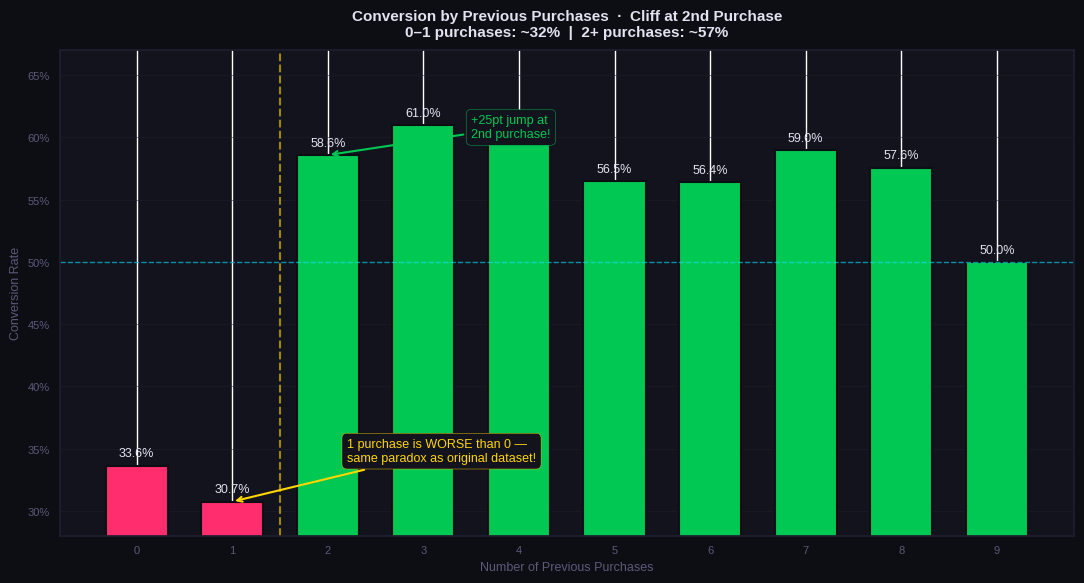

In [ ]:
print('📊 Plot 6: Previous Purchases Cliff')
prev_data = df.groupby('PreviousPurchases')['Conversion'].agg(['mean','count']).reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
style_ax(ax, 'Conversion by Previous Purchases  ·  Cliff at 2nd Purchase\n'
             '0–1 purchases: ~32%  |  2+ purchases: ~57%',
         'Number of Previous Purchases')

bar_colors_pp = [MAGENTA if i <= 1 else GREEN for i in prev_data['PreviousPurchases']]
bars = ax.bar(prev_data['PreviousPurchases'], prev_data['mean'],
              color=bar_colors_pp, edgecolor=BG, linewidth=1.5, width=0.65)
pct_fmt(ax); ax.set_ylim(0.28, 0.67)
ax.set_xticks(prev_data['PreviousPurchases'])
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.6)

for bar, (_, row) in zip(bars, prev_data.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{row['mean']*100:.1f}%", ha='center', va='bottom', color=TEXT, fontsize=9)

ax.annotate('1 purchase is WORSE than 0 —\nsame paradox as original dataset!',
            xy=(1, prev_data[prev_data['PreviousPurchases']==1]['mean'].values[0]),
            xytext=(2.2, 0.34),
            arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.5),
            color=YELLOW, fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=PANEL, edgecolor=YELLOW))

ax.annotate('+25pt jump at\n2nd purchase!',
            xy=(2, prev_data[prev_data['PreviousPurchases']==2]['mean'].values[0]),
            xytext=(3.5, 0.60),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
            color=GREEN, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=PANEL, edgecolor=GREEN))

ax.axvline(1.5, color=YELLOW, linewidth=1.5, linestyle='--', alpha=0.6)
plt.tight_layout()

📊 Plot 7: Email Opens Cliff


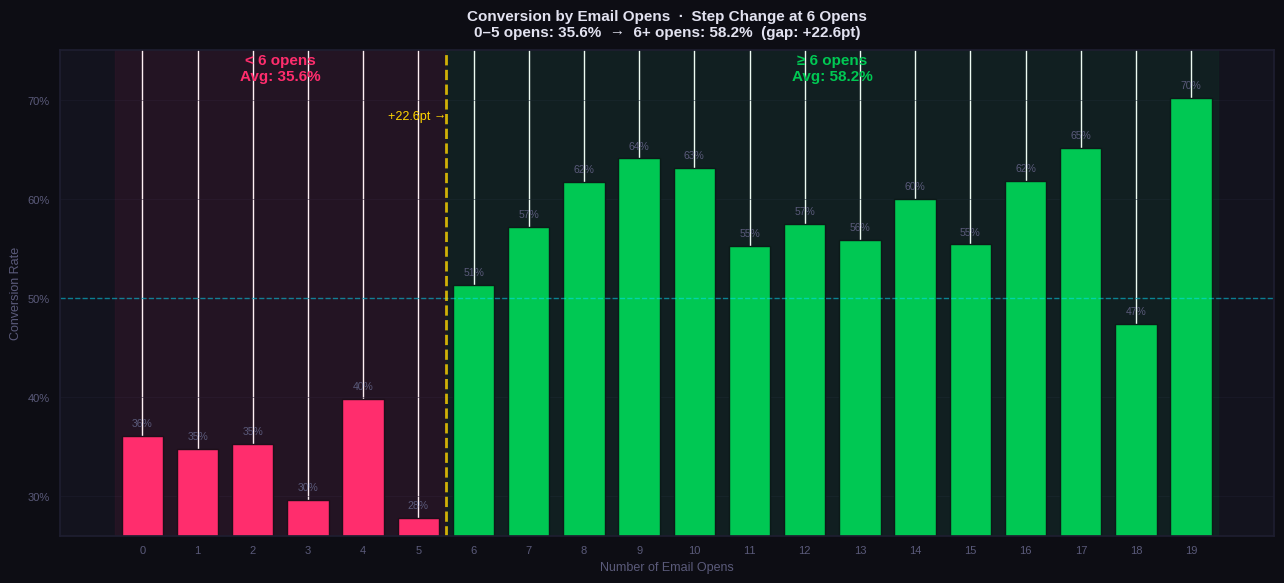

In [ ]:
print('📊 Plot 7: Email Opens Cliff')
email_data = df.groupby('EmailOpens')['Conversion'].mean()

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
style_ax(ax, 'Conversion by Email Opens  ·  Step Change at 6 Opens\n'
             '0–5 opens: 35.6%  →  6+ opens: 58.2%  (gap: +22.6pt)',
         'Number of Email Opens')

bar_colors_eo = [MAGENTA if i < 6 else GREEN for i in email_data.index]
bars = ax.bar(email_data.index, email_data.values, color=bar_colors_eo,
              edgecolor=BG, linewidth=1, width=0.75)
pct_fmt(ax); ax.set_ylim(0.26, 0.75)
ax.set_xticks(email_data.index)
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.5)

for bar, val in zip(bars, email_data.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f'{val*100:.0f}%', ha='center', va='bottom', color=MUTED, fontsize=7.5)

ax.axvline(5.5, color=YELLOW, linewidth=2, linestyle='--', alpha=0.8)
ax.axvspan(-0.5,  5.5, alpha=0.07, color=MAGENTA)
ax.axvspan( 5.5, 19.5, alpha=0.07, color=GREEN)
ax.text(2.5,  0.72, '< 6 opens\nAvg: 35.6%', color=MAGENTA, fontsize=11, fontweight='bold', ha='center')
ax.text(12.5, 0.72, '≥ 6 opens\nAvg: 58.2%', color=GREEN,   fontsize=11, fontweight='bold', ha='center')
ax.text(5.5,  0.68, '+22.6pt →',              color=YELLOW,  fontsize=9,  ha='right')

plt.tight_layout()

📊 Plot 8: Email Clicks Cliff


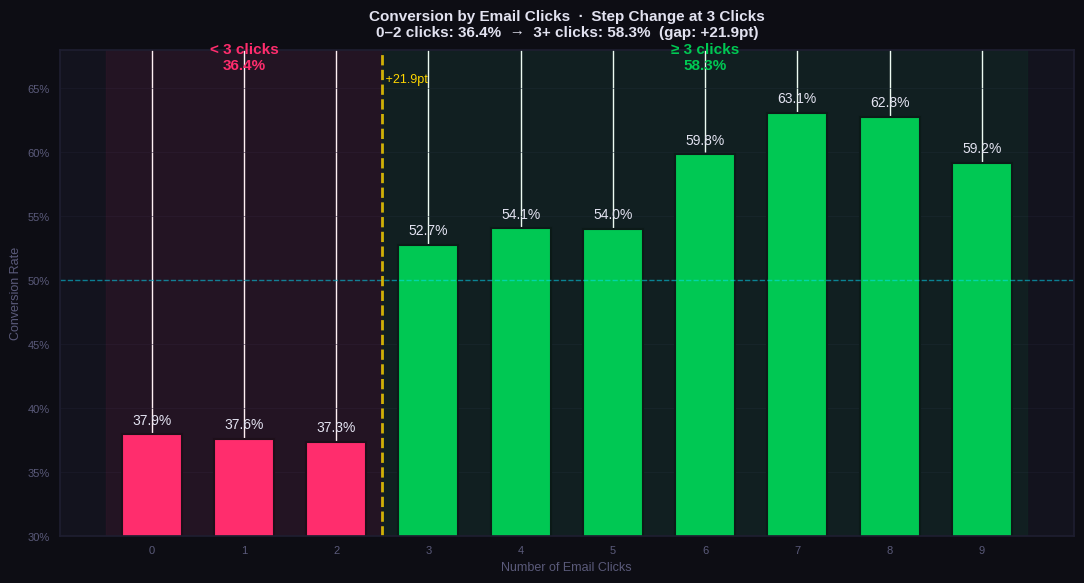

In [ ]:
print('📊 Plot 8: Email Clicks Cliff')
clicks_data = df.groupby('EmailClicks')['Conversion'].mean()

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
style_ax(ax, 'Conversion by Email Clicks  ·  Step Change at 3 Clicks\n'
             '0–2 clicks: 36.4%  →  3+ clicks: 58.3%  (gap: +21.9pt)',
         'Number of Email Clicks')

bar_colors_ec = [MAGENTA if i < 3 else GREEN for i in clicks_data.index]
bars = ax.bar(clicks_data.index, clicks_data.values, color=bar_colors_ec,
              edgecolor=BG, linewidth=1.5, width=0.65)
pct_fmt(ax); ax.set_ylim(0.30, 0.68)
ax.set_xticks(clicks_data.index)
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.5)

for bar, val in zip(bars, clicks_data.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f'{val*100:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=10)

ax.axvline(2.5, color=YELLOW, linewidth=2, linestyle='--', alpha=0.8)
ax.axvspan(-0.5, 2.5, alpha=0.07, color=MAGENTA)
ax.axvspan( 2.5, 9.5, alpha=0.07, color=GREEN)
ax.text(1,   0.665, '< 3 clicks\n36.4%', color=MAGENTA, fontsize=11, fontweight='bold', ha='center')
ax.text(6,   0.665, '≥ 3 clicks\n58.3%', color=GREEN,   fontsize=11, fontweight='bold', ha='center')
ax.text(2.5, 0.655, ' +21.9pt',          color=YELLOW,  fontsize=9)

plt.tight_layout()

📊 Plot 9: Time on Site & Pages Per Visit


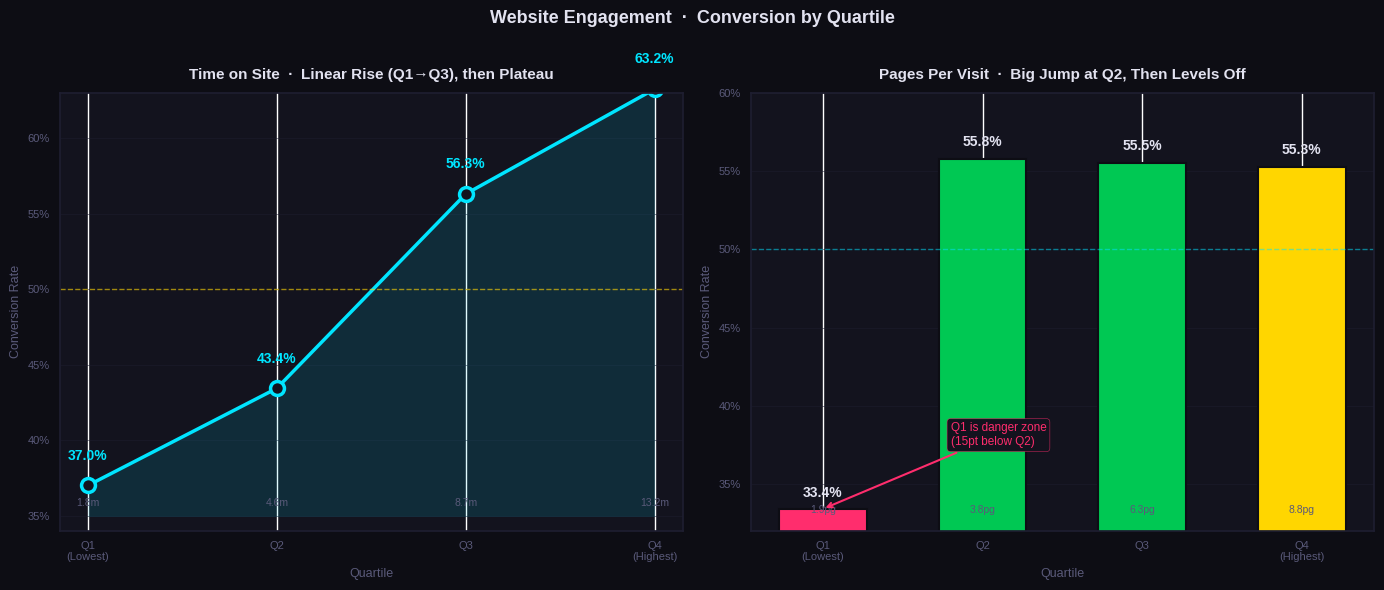

In [ ]:
print('📊 Plot 9: Time on Site & Pages Per Visit')
ql = ['Q1\n(Lowest)','Q2','Q3','Q4\n(Highest)']
qs = ['Q1','Q2','Q3','Q4']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Website Engagement  ·  Conversion by Quartile',
             color=TEXT, fontsize=13, fontweight='bold')

ax = axes[0]
style_ax(ax, 'Time on Site  ·  Linear Rise (Q1→Q3), then Plateau', 'Quartile')
df['TOSQ'] = pd.qcut(df['TimeOnSite'], 4, labels=qs)
tos     = df.groupby('TOSQ', observed=True)['Conversion'].mean()
tos_med = df.groupby('TOSQ', observed=True)['TimeOnSite'].median()
ax.plot(ql, tos.values, color=CYAN, linewidth=2.5, marker='o',
        markersize=10, markerfacecolor=PANEL, markeredgecolor=CYAN, markeredgewidth=2.5)
ax.fill_between(ql, tos.values, 0.35, alpha=0.12, color=CYAN)
pct_fmt(ax); ax.set_ylim(0.34, 0.63)
ax.axhline(0.5, color=YELLOW, linewidth=1, linestyle='--', alpha=0.6)
for x, val, med in zip(ql, tos.values, tos_med.values):
    ax.text(x, val+0.015, f'{val*100:.1f}%', ha='center', va='bottom',
            color=CYAN, fontsize=10, fontweight='bold')
    ax.text(x, 0.355, f'{med:.1f}m', ha='center', va='bottom', color=MUTED, fontsize=7.5)

ax = axes[1]
style_ax(ax, 'Pages Per Visit  ·  Big Jump at Q2, Then Levels Off', 'Quartile')
df['PPVQ']  = pd.qcut(df['PagesPerVisit'], 4, labels=qs)
ppv     = df.groupby('PPVQ', observed=True)['Conversion'].mean()
ppv_med = df.groupby('PPVQ', observed=True)['PagesPerVisit'].median()
bar_colors_ppv = [MAGENTA, GREEN, GREEN, YELLOW]
bars = ax.bar(ql, ppv.values, color=bar_colors_ppv, edgecolor=BG, linewidth=1.5, width=0.55)
pct_fmt(ax); ax.set_ylim(0.32, 0.60)
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.5)
for bar, val, med in zip(bars, ppv.values, ppv_med.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f'{val*100:.1f}%', ha='center', va='bottom', color=TEXT,
            fontsize=10, fontweight='bold')
    ax.text(bar.get_x()+bar.get_width()/2, 0.33, f'{med:.1f}pg',
            ha='center', va='bottom', color=MUTED, fontsize=7.5)

ax.annotate('Q1 is danger zone\n(15pt below Q2)',
            xy=(0, ppv.values[0]),
            xytext=(0.8, 0.375),
            arrowprops=dict(arrowstyle='->', color=MAGENTA, lw=1.5),
            color=MAGENTA, fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PANEL, edgecolor=MAGENTA))

plt.tight_layout()

📊 Plot 10: Bounce Analysis


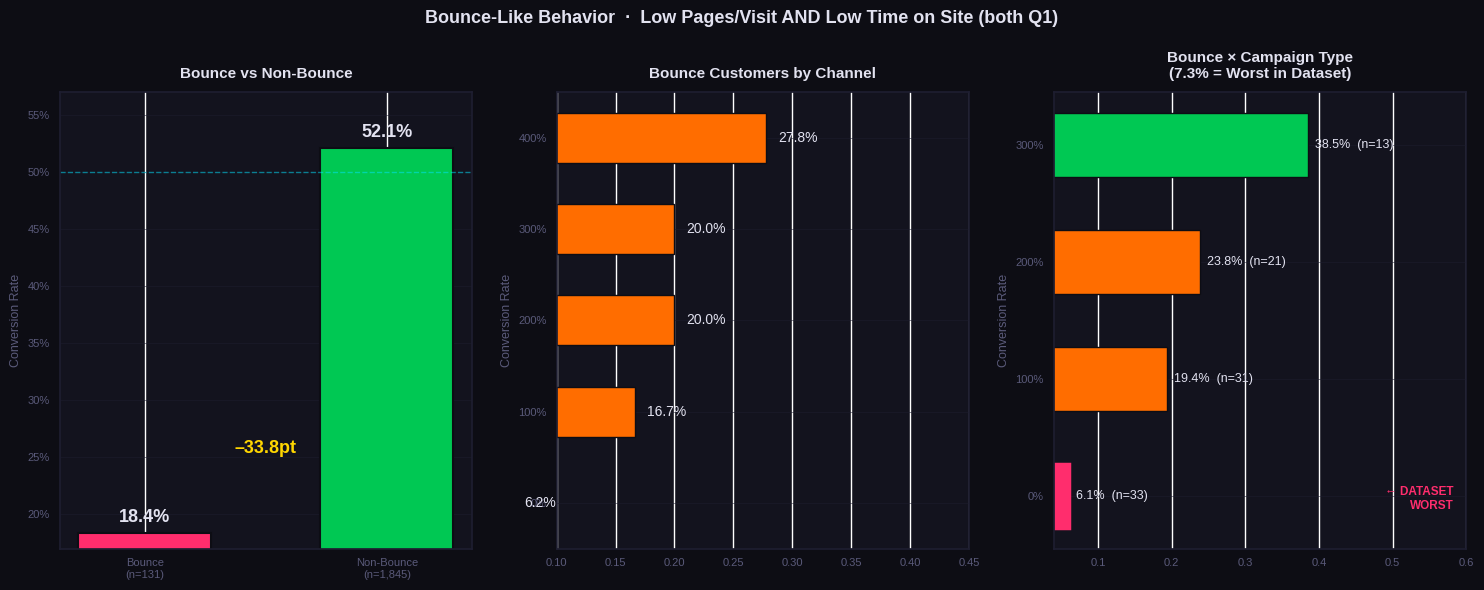

In [ ]:
print('📊 Plot 10: Bounce Analysis')
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Bounce-Like Behavior  ·  Low Pages/Visit AND Low Time on Site (both Q1)',
             color=TEXT, fontsize=13, fontweight='bold')

ax = axes[0]
style_ax(ax, 'Bounce vs Non-Bounce', '')
bv  = df[df['Bounce']]['Conversion'].mean()
nbv = df[~df['Bounce']]['Conversion'].mean()
bars = ax.bar(['Bounce\n(n=131)', 'Non-Bounce\n(n=1,845)'],
              [bv, nbv], color=[MAGENTA, GREEN], edgecolor=BG, linewidth=1.5, width=0.55)
pct_fmt(ax); ax.set_ylim(0.17, 0.57)
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.5)
for bar, val in zip(bars, [bv, nbv]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f'{val*100:.1f}%', ha='center', va='bottom', color=TEXT,
            fontsize=13, fontweight='bold')
ax.text(0.5, 0.20, f'–{(nbv-bv)*100:.1f}pt', ha='center', va='bottom',
        color=YELLOW, fontsize=13, fontweight='bold',
        transform=ax.get_xaxis_transform())

ax = axes[1]
style_ax(ax, 'Bounce Customers by Channel', '')
bch = df[df['Bounce']].groupby('CampaignChannel')['Conversion'].mean().sort_values()
ax.barh(bch.index, bch.values,
        color=[bar_color(v, low=0.15, high=0.30) for v in bch.values],
        edgecolor=BG, linewidth=1, height=0.55)
pct_fmt(ax); ax.set_xlim(0.10, 0.45)
for val, y in zip(bch.values, range(len(bch))):
    ax.text(val+0.01, y, f'{val*100:.1f}%', va='center', color=TEXT, fontsize=10)

ax = axes[2]
style_ax(ax, 'Bounce × Campaign Type\n(7.3% = Worst in Dataset)', '')
bct  = df[df['Bounce']].groupby('CampaignType')['Conversion'].agg(['mean','count']).sort_values('mean')
bars = ax.barh(bct.index, bct['mean'],
               color=[bar_color(v, low=0.15, high=0.35) for v in bct['mean']],
               edgecolor=BG, linewidth=1, height=0.55)
pct_fmt(ax); ax.set_xlim(0.04, 0.60)
for bar, (lbl, row) in zip(bars, bct.iterrows()):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f"{row['mean']*100:.1f}%  (n={int(row['count'])})",
            va='center', color=TEXT, fontsize=9)
worst_idx = list(bct.index).index(bct['mean'].idxmin())
bars[worst_idx].set_edgecolor(MAGENTA)
bars[worst_idx].set_linewidth(2.5)
ax.text(0.97, 0.08, '← DATASET\nWORST',
        transform=ax.transAxes, ha='right', va='bottom',
        color=MAGENTA, fontsize=8.5, fontweight='bold')

plt.tight_layout()

📊 Plot 11: Channel × Campaign Type Heatmap


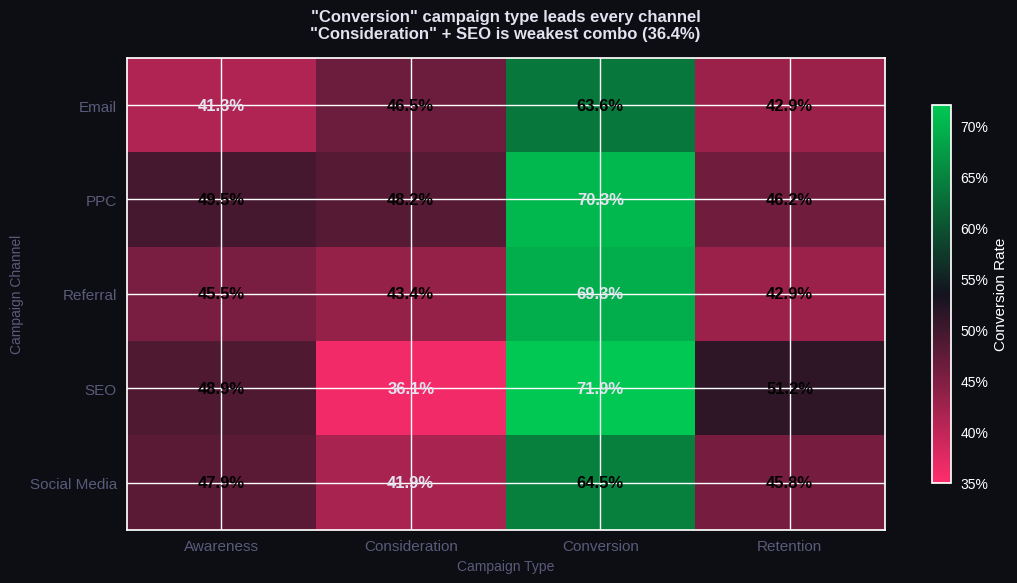

In [ ]:
print('📊 Plot 11: Channel × Campaign Type Heatmap')
ct_matrix = df.groupby(['CampaignChannel','CampaignType'])['Conversion'].mean().unstack()

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
cmap = LinearSegmentedColormap.from_list('rg', [MAGENTA, PANEL, GREEN])
im   = ax.imshow(ct_matrix.values, cmap=cmap, aspect='auto', vmin=0.35, vmax=0.72)

ax.set_xticks(range(len(ct_matrix.columns)))
ax.set_yticks(range(len(ct_matrix.index)))
ax.set_xticklabels(ct_matrix.columns, color=TEXT, fontsize=11)
ax.set_yticklabels(ct_matrix.index,   color=TEXT, fontsize=11)
ax.tick_params(colors=MUTED)

for i in range(len(ct_matrix.index)):
    for j in range(len(ct_matrix.columns)):
        val = ct_matrix.values[i, j]
        c   = 'black' if 0.42 < val < 0.65 else TEXT
        ax.text(j, i, f'{val*100:.1f}%', ha='center', va='center',
                color=c, fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, format=plt.FuncFormatter(lambda v,_: f'{v*100:.0f}%'),
             label='Conversion Rate', shrink=0.8)
ax.set_title('"Conversion" campaign type leads every channel\n'
             '"Consideration" + SEO is weakest combo (36.4%)',
             color=TEXT, fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Campaign Type',    color=MUTED, fontsize=10)
ax.set_ylabel('Campaign Channel', color=MUTED, fontsize=10)
ax.set_facecolor(PANEL)
plt.tight_layout()

📊 Plot 12: Loyalty × Ad Spend Matrix


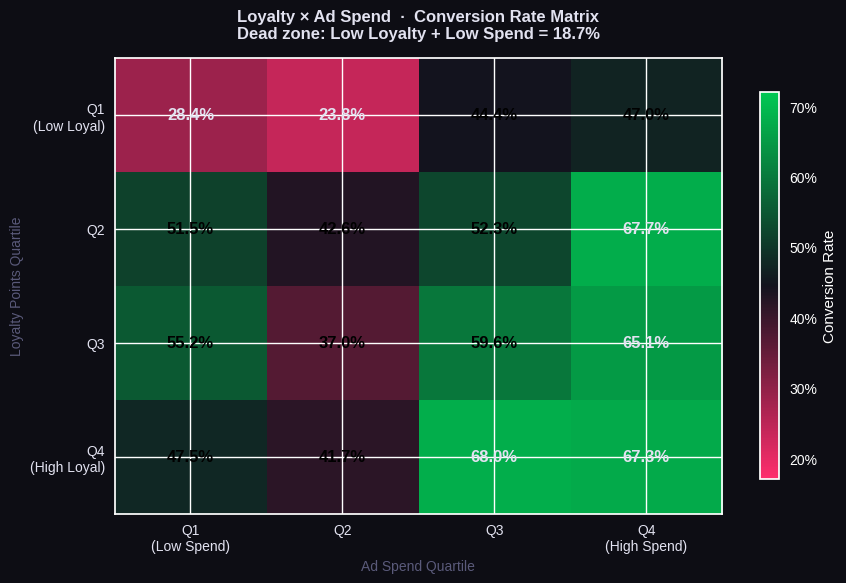

In [ ]:
print('📊 Plot 12: Loyalty × Ad Spend Matrix')
ls_matrix = df.groupby(['LQ','SQ'], observed=True)['Conversion'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG)
cmap2 = LinearSegmentedColormap.from_list('rg', [MAGENTA, PANEL, GREEN])
im2   = ax.imshow(ls_matrix.values, cmap=cmap2, aspect='auto', vmin=0.17, vmax=0.72)

ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(['Q1\n(Low Spend)','Q2','Q3','Q4\n(High Spend)'], color=TEXT, fontsize=10)
ax.set_yticklabels(['Q1\n(Low Loyal)','Q2','Q3','Q4\n(High Loyal)'], color=TEXT, fontsize=10)

for i in range(4):
    for j in range(4):
        val = ls_matrix.values[i, j]
        c   = 'black' if 0.35 < val < 0.60 else TEXT
        ax.text(j, i, f'{val*100:.1f}%', ha='center', va='center',
                color=c, fontsize=12, fontweight='bold')

plt.colorbar(im2, ax=ax, format=plt.FuncFormatter(lambda v,_: f'{v*100:.0f}%'),
             label='Conversion Rate', shrink=0.85)
ax.set_title('Loyalty × Ad Spend  ·  Conversion Rate Matrix\n'
             'Dead zone: Low Loyalty + Low Spend = 18.7%',
             color=TEXT, fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Ad Spend Quartile',       color=MUTED, fontsize=10)
ax.set_ylabel('Loyalty Points Quartile', color=MUTED, fontsize=10)
ax.set_facecolor(PANEL)
plt.tight_layout()

📊 Plot 15: Ad Spend Threshold Testing


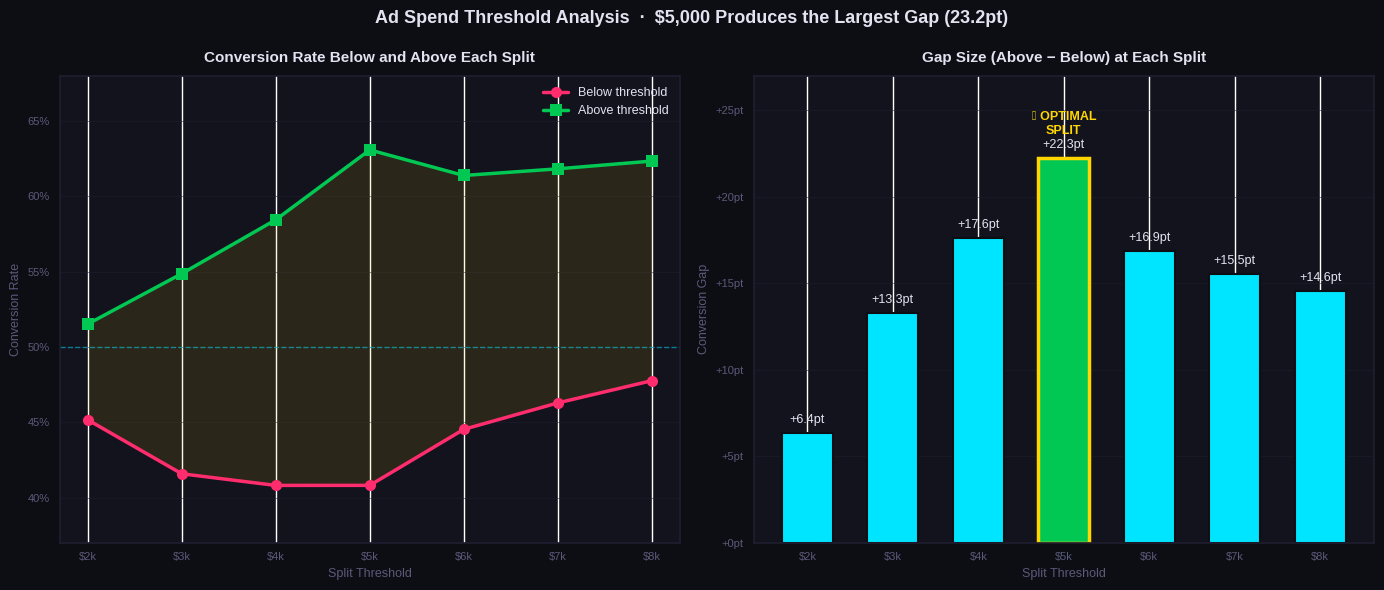

In [ ]:
print('📊 Plot 15: Ad Spend Threshold Testing')
splits      = [2000, 3000, 4000, 5000, 6000, 7000, 8000]
below_rates = [df[df['AdSpend'] <= s]['Conversion'].mean() for s in splits]
above_rates = [df[df['AdSpend']  > s]['Conversion'].mean() for s in splits]
gaps        = [a - b for a, b in zip(above_rates, below_rates)]
xlabels     = [f'${s//1000}k' for s in splits]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Ad Spend Threshold Analysis  ·  $5,000 Produces the Largest Gap (23.2pt)',
             color=TEXT, fontsize=13, fontweight='bold')

ax = axes[0]
style_ax(ax, 'Conversion Rate Below and Above Each Split', 'Split Threshold')
ax.plot(xlabels, below_rates, color=MAGENTA, linewidth=2.5, marker='o',
        markersize=8, label='Below threshold')
ax.plot(xlabels, above_rates, color=GREEN,   linewidth=2.5, marker='s',
        markersize=8, label='Above threshold')
ax.fill_between(xlabels, below_rates, above_rates, alpha=0.10, color=YELLOW)
pct_fmt(ax); ax.set_ylim(0.37, 0.68)
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.5)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT, fontsize=9)

ax = axes[1]
style_ax(ax, 'Gap Size (Above − Below) at Each Split', 'Split Threshold', 'Conversion Gap')
bar_colors_split = [GREEN if g == max(gaps) else CYAN for g in gaps]
bars = ax.bar(xlabels, gaps, color=bar_colors_split, edgecolor=BG, linewidth=1.5, width=0.6)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'+{v*100:.0f}pt'))
ax.set_ylim(0, 0.27)
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'+{val*100:.1f}pt', ha='center', va='bottom', color=TEXT, fontsize=9)
max_idx = gaps.index(max(gaps))
bars[max_idx].set_edgecolor(YELLOW)
bars[max_idx].set_linewidth(2.5)
ax.text(max_idx, max(gaps)+0.012, '★ OPTIMAL\nSPLIT',
        ha='center', va='bottom', color=YELLOW, fontsize=9, fontweight='bold')

plt.tight_layout()

📊 Plot 16: Email Click Efficiency


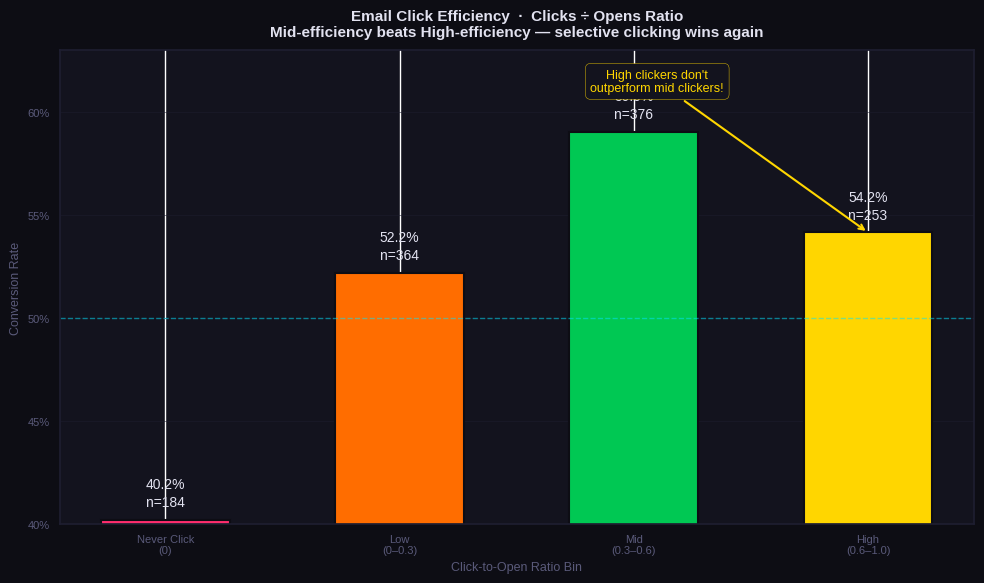

In [ ]:
print('📊 Plot 16: Email Click Efficiency')
df_opens = df[df['EmailOpens'] > 0].copy()
df_opens['ClickRatio'] = df_opens['EmailClicks'] / df_opens['EmailOpens']
df_opens['EffBin'] = pd.cut(df_opens['ClickRatio'],
                             bins=[-0.01, 0, 0.3, 0.6, 1.01],
                             labels=['Never Click\n(0)','Low\n(0–0.3)',
                                     'Mid\n(0.3–0.6)','High\n(0.6–1.0)'])
eff = df_opens.groupby('EffBin', observed=True)['Conversion'].agg(['mean','count'])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
style_ax(ax, 'Email Click Efficiency  ·  Clicks ÷ Opens Ratio\n'
             'Mid-efficiency beats High-efficiency — selective clicking wins again',
         'Click-to-Open Ratio Bin')

bar_colors_eff = [MAGENTA, ORANGE, GREEN, YELLOW]
bars = ax.bar(eff.index, eff['mean'], color=bar_colors_eff,
              edgecolor=BG, linewidth=1.5, width=0.55)
pct_fmt(ax); ax.set_ylim(0.40, 0.63)
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.5)

for bar, (idx, row) in zip(bars, eff.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{row['mean']*100:.1f}%\nn={int(row['count']):,}",
            ha='center', va='bottom', color=TEXT, fontsize=10, linespacing=1.4)

ax.annotate('High clickers don\'t\noutperform mid clickers!',
            xy=(3, eff['mean'].iloc[3]),
            xytext=(2.1, 0.61),
            arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.5),
            color=YELLOW, fontsize=9, ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=PANEL, edgecolor=YELLOW))

plt.tight_layout()

📊 Plot 18: New Customer Profile Comparison


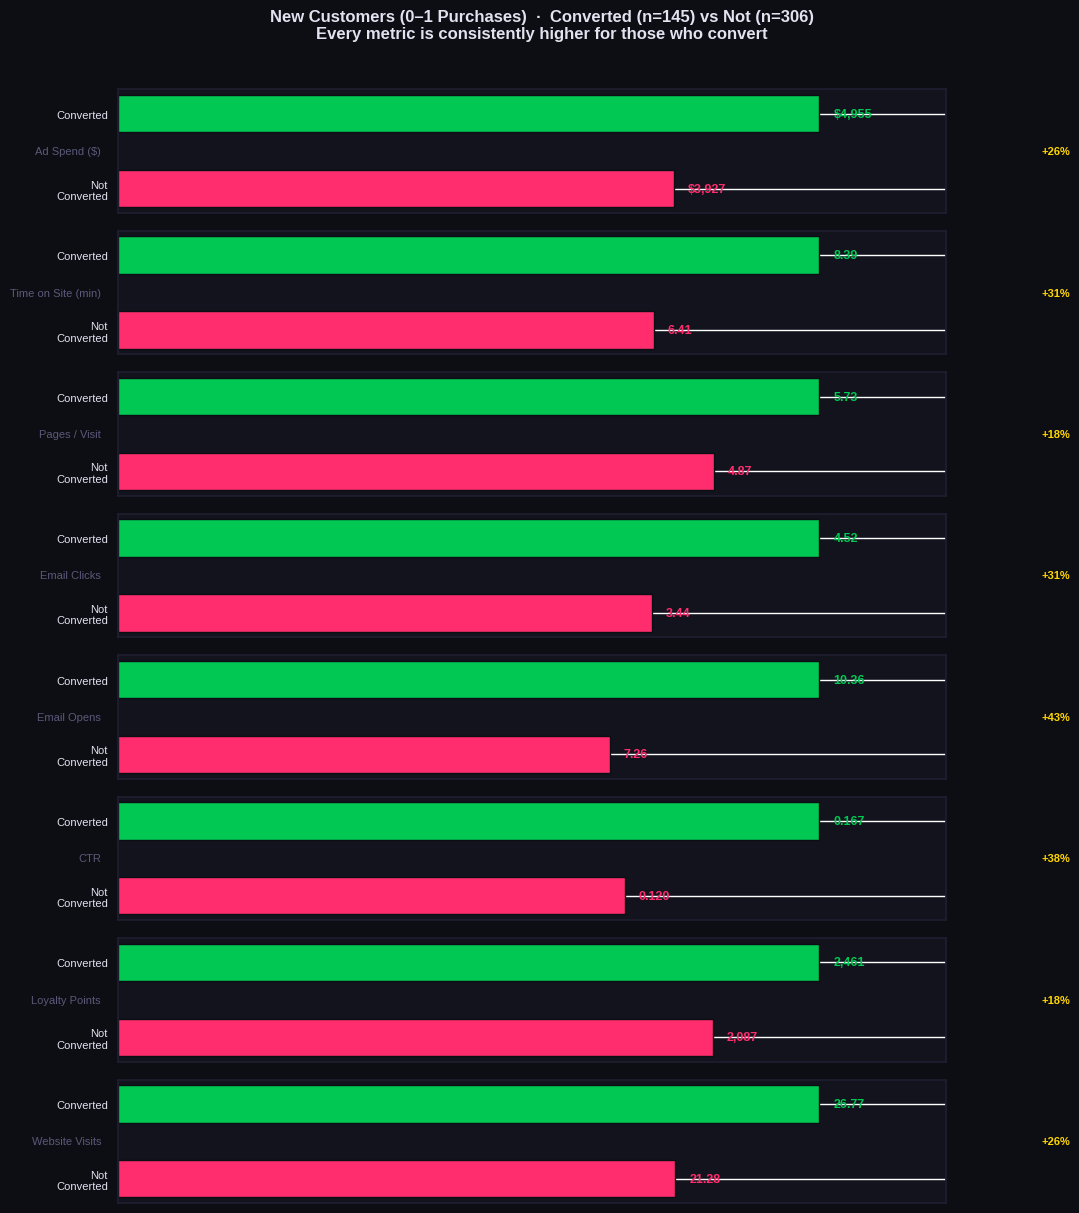

In [ ]:
print('📊 Plot 18: New Customer Profile Comparison')
new      = df[df['PreviousPurchases'] <= 1]
conv_new = new[new['Conversion'] == 1]
nc_new   = new[new['Conversion'] == 0]

metrics = ['AdSpend','TimeOnSite','PagesPerVisit','EmailClicks',
           'EmailOpens','ClickThroughRate','LoyaltyPoints','WebsiteVisits']
labels  = ['Ad Spend ($)','Time on Site (min)','Pages / Visit','Email Clicks',
           'Email Opens','CTR','Loyalty Points','Website Visits']

cv  = conv_new[metrics].mean()
ncv = nc_new[metrics].mean()

fig, axes = plt.subplots(len(metrics), 1, figsize=(11, 12))
fig.patch.set_facecolor(BG)
fig.suptitle(f'New Customers (0–1 Purchases)  ·  Converted (n={len(conv_new)}) vs Not (n={len(nc_new)})\n'
              'Every metric is consistently higher for those who convert',
             color=TEXT, fontsize=12, fontweight='bold', y=1.01)

for ax, metric, label, c_val, n_val in zip(axes, metrics, labels, cv, ncv):
    ax.set_facecolor(PANEL)
    total = max(c_val, n_val)
    ax.barh(['Not Converted','Converted'], [n_val/total, c_val/total],
            color=[MAGENTA, GREEN], height=0.5, edgecolor=BG, linewidth=1)
    ax.set_xlim(0, 1.18); ax.set_yticks([0, 1])
    ax.set_yticklabels(['Not\nConverted','Converted'], color=TEXT, fontsize=8)
    ax.set_xticks([])
    for sp in ax.spines.values():
        sp.set_color(GRID_C)

    fmt = '${:,.0f}' if metric == 'AdSpend' else '{:,.0f}' if metric == 'LoyaltyPoints' \
          else '{:.3f}' if metric == 'ClickThroughRate' else '{:.2f}'
    ax.text(n_val/total+0.02, 0, fmt.format(n_val), va='center',
            color=MAGENTA, fontsize=9, fontweight='bold')
    ax.text(c_val/total+0.02, 1, fmt.format(c_val), va='center',
            color=GREEN,   fontsize=9, fontweight='bold')
    ax.text(-0.02, 0.5, label, ha='right', va='center',
            color=MUTED, fontsize=8, transform=ax.transAxes)
    pct_diff = (c_val - n_val) / n_val * 100
    ax.text(1.15, 0.5, f'+{pct_diff:.0f}%', ha='right', va='center',
            color=YELLOW, fontsize=8, fontweight='bold', transform=ax.transAxes)

plt.tight_layout()

📊 Plot 19: Composite Engagement Score


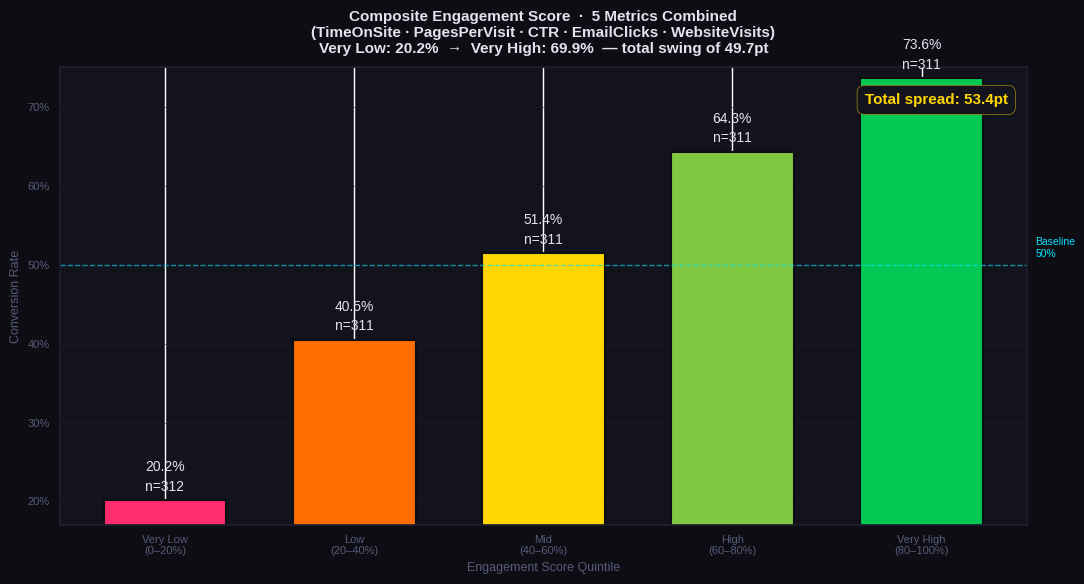

In [ ]:
print('📊 Plot 19: Composite Engagement Score')
eng_data = df.groupby('EngBin', observed=True)['Conversion'].agg(['mean','count'])
eng_lbls = ['Very Low\n(0–20%)','Low\n(20–40%)','Mid\n(40–60%)',
            'High\n(60–80%)','Very High\n(80–100%)']

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
style_ax(ax, 'Composite Engagement Score  ·  5 Metrics Combined\n'
             '(TimeOnSite · PagesPerVisit · CTR · EmailClicks · WebsiteVisits)\n'
             'Very Low: 20.2%  →  Very High: 69.9%  — total swing of 49.7pt',
         'Engagement Score Quintile')

colors_eng = [MAGENTA, ORANGE, YELLOW, '#80c840', GREEN]
bars = ax.bar(eng_lbls, eng_data['mean'], color=colors_eng,
              edgecolor=BG, linewidth=1.5, width=0.65)
pct_fmt(ax); ax.set_ylim(0.17, 0.75)
ax.axhline(0.5, color=CYAN, linewidth=1, linestyle='--', alpha=0.6)
ax.text(4.6, 0.51, 'Baseline\n50%', color=CYAN, fontsize=7.5)

for bar, (_, row) in zip(bars, eng_data.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{row['mean']*100:.1f}%\nn={int(row['count'])}",
            ha='center', va='bottom', color=TEXT, fontsize=10, linespacing=1.5)

gap = eng_data['mean'].max() - eng_data['mean'].min()
ax.text(0.98, 0.92, f'Total spread: {gap*100:.1f}pt',
        transform=ax.transAxes, ha='right', color=YELLOW, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=PANEL, edgecolor=YELLOW))

plt.tight_layout()

📊 Plot 20: Summary Dashboard


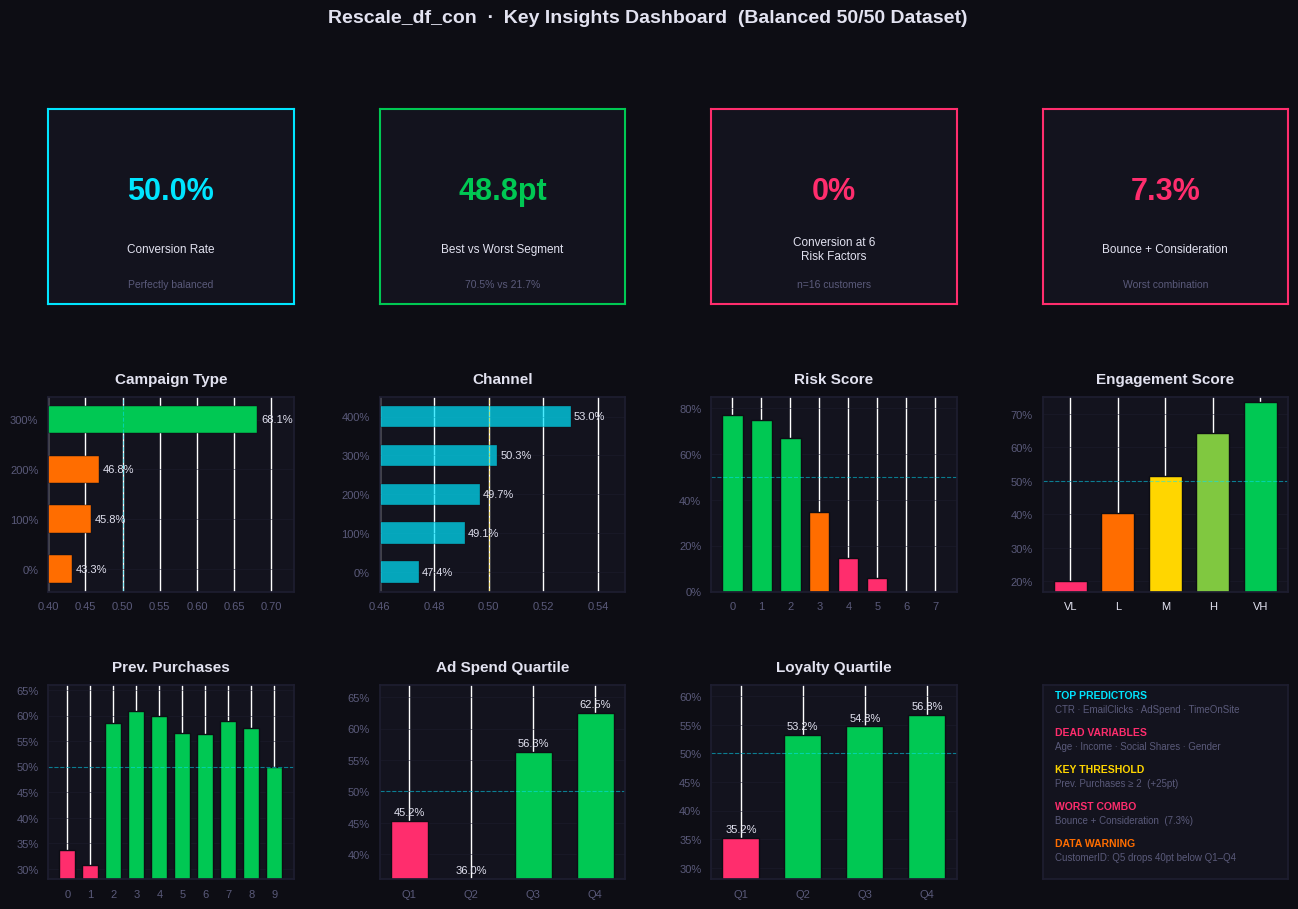

In [ ]:
print('📊 Plot 20: Summary Dashboard')
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('Rescale_df_con  ·  Key Insights Dashboard  (Balanced 50/50 Dataset)',
             color=TEXT, fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.35)

def kpi(ax, value, label, sublabel='', color=GREEN):
    ax.set_facecolor(PANEL); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_color(color); sp.set_linewidth(1.5)
    ax.text(0.5, 0.58, value, ha='center', va='center', fontsize=22,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center', fontsize=8.5,
            color=TEXT, transform=ax.transAxes)
    if sublabel:
        ax.text(0.5, 0.10, sublabel, ha='center', va='center', fontsize=7.5,
                color=MUTED, transform=ax.transAxes)

ax1 = fig.add_subplot(gs[0,0]); kpi(ax1, '50.0%', 'Conversion Rate', 'Perfectly balanced', CYAN)
ax2 = fig.add_subplot(gs[0,1]); kpi(ax2, '48.8pt', 'Best vs Worst Segment', '70.5% vs 21.7%', GREEN)
ax3 = fig.add_subplot(gs[0,2]); kpi(ax3, '0%', 'Conversion at 6\nRisk Factors', 'n=16 customers', MAGENTA)
ax4 = fig.add_subplot(gs[0,3]); kpi(ax4, '7.3%', 'Bounce + Consideration', 'Worst combination', MAGENTA)

ax5 = fig.add_subplot(gs[1,0])
style_ax(ax5, 'Campaign Type', ylabel='')
ct_s = df.groupby('CampaignType')['Conversion'].mean().sort_values()
ax5.barh(ct_s.index, ct_s.values,
         color=[bar_color(v, low=0.43, high=0.60) for v in ct_s.values],
         height=0.55, edgecolor=BG)
pct_fmt(ax5); ax5.set_xlim(0.40, 0.73)
ax5.axvline(0.5, color=CYAN, linewidth=0.8, linestyle='--', alpha=0.5)
for i, (_, val) in enumerate(ct_s.items()):
    ax5.text(val+0.005, i, f'{val*100:.1f}%', va='center', color=TEXT, fontsize=8)

ax6 = fig.add_subplot(gs[1,1])
style_ax(ax6, 'Channel', ylabel='')
ch_s = df.groupby('CampaignChannel')['Conversion'].mean().sort_values()
ax6.barh(ch_s.index, ch_s.values, color=CYAN, alpha=0.7, height=0.55, edgecolor=BG)
pct_fmt(ax6); ax6.set_xlim(0.46, 0.55)
ax6.axvline(0.5, color=YELLOW, linewidth=0.8, linestyle='--', alpha=0.5)
for i, (_, val) in enumerate(ch_s.items()):
    ax6.text(val+0.001, i, f'{val*100:.1f}%', va='center', color=TEXT, fontsize=8)

ax7 = fig.add_subplot(gs[1,2])
style_ax(ax7, 'Risk Score', ylabel='')
rk = df.groupby('RiskScore')['Conversion'].mean()
ax7.bar(rk.index, rk.values,
        color=[bar_color(v, low=0.20, high=0.55) for v in rk.values],
        edgecolor=BG, linewidth=1, width=0.7)
pct_fmt(ax7); ax7.set_ylim(0, 0.85)
ax7.axhline(0.5, color=CYAN, linewidth=0.8, linestyle='--', alpha=0.5)
ax7.set_xticks(rk.index)

ax8 = fig.add_subplot(gs[1,3])
style_ax(ax8, 'Engagement Score', ylabel='')
eg = df.groupby('EngBin', observed=True)['Conversion'].mean()
ax8.bar(range(5), eg.values, color=colors_eng, edgecolor=BG, linewidth=1, width=0.7)
pct_fmt(ax8); ax8.set_ylim(0.17, 0.75)
ax8.axhline(0.5, color=CYAN, linewidth=0.8, linestyle='--', alpha=0.5)
ax8.set_xticks(range(5))
ax8.set_xticklabels(['VL','L','M','H','VH'], color=TEXT, fontsize=8)

ax9 = fig.add_subplot(gs[2,0])
style_ax(ax9, 'Prev. Purchases', ylabel='')
pp = df.groupby('PreviousPurchases')['Conversion'].mean()
ax9.bar(pp.index, pp.values,
        color=[MAGENTA if i<=1 else GREEN for i in pp.index],
        edgecolor=BG, linewidth=1, width=0.7)
pct_fmt(ax9); ax9.set_ylim(0.28, 0.66)
ax9.axhline(0.5, color=CYAN, linewidth=0.8, linestyle='--', alpha=0.5)
ax9.set_xticks(pp.index)

ax10 = fig.add_subplot(gs[2,1])
style_ax(ax10, 'Ad Spend Quartile', ylabel='')
sq = df.groupby('SQ', observed=True)['Conversion'].mean()
ax10.bar(['Q1','Q2','Q3','Q4'], sq.values,
         color=[MAGENTA, MAGENTA, GREEN, GREEN], edgecolor=BG, linewidth=1, width=0.6)
pct_fmt(ax10); ax10.set_ylim(0.36, 0.67)
ax10.axhline(0.5, color=CYAN, linewidth=0.8, linestyle='--', alpha=0.5)
for x, val in zip(['Q1','Q2','Q3','Q4'], sq.values):
    ax10.text(x, val+0.006, f'{val*100:.1f}%', ha='center', va='bottom',
              color=TEXT, fontsize=8)

ax11 = fig.add_subplot(gs[2,2])
style_ax(ax11, 'Loyalty Quartile', ylabel='')
lq = df.groupby('LQ', observed=True)['Conversion'].mean()
ax11.bar(['Q1','Q2','Q3','Q4'], lq.values,
         color=[MAGENTA, GREEN, GREEN, GREEN], edgecolor=BG, linewidth=1, width=0.6)
pct_fmt(ax11); ax11.set_ylim(0.28, 0.62)
ax11.axhline(0.5, color=CYAN, linewidth=0.8, linestyle='--', alpha=0.5)
for x, val in zip(['Q1','Q2','Q3','Q4'], lq.values):
    ax11.text(x, val+0.006, f'{val*100:.1f}%', ha='center', va='bottom',
              color=TEXT, fontsize=8)

ax12 = fig.add_subplot(gs[2,3])
ax12.set_facecolor(PANEL); ax12.set_xticks([]); ax12.set_yticks([])
for sp in ax12.spines.values():
    sp.set_color(GRID_C)
findings = [
    ('TOP PREDICTORS',  'CTR · EmailClicks · AdSpend · TimeOnSite', CYAN),
    ('DEAD VARIABLES',  'Age · Income · Social Shares · Gender',     MAGENTA),
    ('KEY THRESHOLD',   'Prev. Purchases ≥ 2  (+25pt)',              YELLOW),
    ('WORST COMBO',     'Bounce + Consideration  (7.3%)',            MAGENTA),
    ('DATA WARNING',    'CustomerID: Q5 drops 40pt below Q1–Q4',     ORANGE),
]
y_pos = 0.93
for title, desc, color in findings:
    ax12.text(0.05, y_pos,      title, transform=ax12.transAxes,
              color=color, fontsize=7.5, fontweight='bold')
    ax12.text(0.05, y_pos-0.07, desc,  transform=ax12.transAxes,
              color=MUTED, fontsize=7)
    y_pos -= 0.19

In [ ]:
df['Gender'].value_counts()

In [ ]:
error_check1 = df[(df['WebsiteVisits'] == 0) & (df['TimeOnSite'] > 0)].value_counts()

In [ ]:
error_check2 = df[(df['WebsiteVisits'] == 0) & (df['PagesPerVisit'] > 0)]

In [ ]:

df_cleaned = df.copy()

# Fix 1: Impute Email Opens (Logical Fix)
df_cleaned.loc[(df_cleaned['EmailOpens'] == 0) & (df_cleaned['EmailClicks'] > 0), 'EmailOpens'] = 1

# Fix 2: Drop Website Logic Errors (Noise Removal)
mask_website_error = (df_cleaned['WebsiteVisits'] == 0) & ((df_cleaned['TimeOnSite'] > 0) | (df_cleaned['PagesPerVisit'] > 0))
df_cleaned = df_cleaned[~mask_website_error]

print(f"Original Rows: {len(df)}")
print(f"Cleaned Rows: {len(df_cleaned)}")
print(f"Removed {len(df) - len(df_cleaned)} impossible website sessions.")

Original Rows: 1556
Cleaned Rows: 1522
Removed 34 impossible website sessions.


In [ ]:
df

In [ ]:

s = setup(data=df,
          target='Conversion',
          session_id=8717,
          normalize=True,          # Handles your Normalization/Standardization
          transformation=True,     # Fixes skewed data
          ignore_features=['CustomerID','AdvertisingPlatform','AdvertisingTool']) # Drops the useless column
best_model = compare_models()

,Description,Value
0,Session id,8717
1,Target,Conversion
2,Target type,Binary
3,Original data shape,"(1556, 20)"
4,Transformed data shape,"(1556, 24)"
5,Transformed train set shape,"(1089, 24)"
6,Transformed test set shape,"(467, 24)"
7,Ignore features,3
8,Numeric features,13
9,Categorical features,3


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.7484,0.8085,0.7615,0.7449,0.7515,0.4968,0.4991,0.4530
gbc,Gradient Boosting Classifier,0.7475,0.8114,0.7616,0.7433,0.7512,0.4950,0.4966,0.8820
lightgbm,Light Gradient Boosting Machine,0.7429,0.8044,0.7470,0.7431,0.7437,0.4858,0.4876,0.4110
lr,Logistic Regression,0.7337,0.8015,0.7231,0.7413,0.7299,0.4675,0.4700,1.0420
ridge,Ridge Classifier,0.7310,0.8023,0.7194,0.7395,0.7271,0.4620,0.4644,0.1530
rf,Random Forest Classifier,0.7310,0.8115,0.7175,0.7407,0.7270,0.4619,0.4643,0.5550
lda,Linear Discriminant Analysis,0.7310,0.8023,0.7194,0.7395,0.7271,0.4620,0.4644,0.1500
et,Extra Trees Classifier,0.7273,0.7867,0.7268,0.7282,0.7268,0.4548,0.4557,0.3470
ada,Ada Boost Classifier,0.7254,0.8033,0.6938,0.7433,0.7162,0.4510,0.4536,0.3080
nb,Naive Bayes,0.7172,0.7989,0.6829,0.7339,0.7057,0.4346,0.4374,0.1450


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
df_cleaned

In [ ]:
s = setup(data=df_cleaned,
          target='Conversion',
          session_id=8717,
          normalize=True,          # Handles your Normalization/Standardization
          transformation=True,     # Fixes skewed data
          ignore_features=['CustomerID','AdvertisingPlatform','AdvertisingTool']) # Drops the useless column
best_model = compare_models()

,Description,Value
0,Session id,8717
1,Target,Conversion
2,Target type,Binary
3,Original data shape,"(1522, 20)"
4,Transformed data shape,"(1522, 24)"
5,Transformed train set shape,"(1065, 24)"
6,Transformed test set shape,"(457, 24)"
7,Ignore features,3
8,Numeric features,13
9,Categorical features,3


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7521,0.8206,0.7570,0.7513,0.7529,0.5042,0.5058,0.5280
lightgbm,Light Gradient Boosting Machine,0.7483,0.8186,0.7456,0.7519,0.7482,0.4965,0.4972,0.6670
rf,Random Forest Classifier,0.7474,0.8201,0.7459,0.7507,0.7476,0.4949,0.4957,0.5580
lr,Logistic Regression,0.7464,0.8063,0.7345,0.7553,0.7434,0.4929,0.4947,0.1810
ridge,Ridge Classifier,0.7464,0.8073,0.7345,0.7554,0.7434,0.4929,0.4948,0.1460
lda,Linear Discriminant Analysis,0.7464,0.8073,0.7345,0.7554,0.7434,0.4929,0.4948,0.2490
ada,Ada Boost Classifier,0.7286,0.8033,0.7046,0.7447,0.7231,0.4573,0.4591,0.2860
xgboost,Extreme Gradient Boosting,0.7267,0.8119,0.7268,0.7282,0.7263,0.4533,0.4547,0.2890
et,Extra Trees Classifier,0.7136,0.7853,0.7067,0.7204,0.7122,0.4273,0.4289,0.3630
nb,Naive Bayes,0.7089,0.7984,0.6616,0.7335,0.6945,0.4180,0.4212,0.1460


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
import pickle

with open('model_v1.pkl', 'wb') as file:
    pickle.dump(best_model, file)

# Hyperparameter Tuning

In [ ]:
df_transformed = pd.get_dummies(df, columns=['CampaignChannel', 'CampaignType'], drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_transformed.drop(columns = ['CustomerID','AdvertisingPlatform','AdvertisingTool','Conversion'])
y = df_transformed['Conversion']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)

In [ ]:
y = pd.get_dummies(y)

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize
scaler = StandardScaler()

# 2. Fit and Transform training data
X_train_scaled = scaler.fit_transform(X_train[['Age', 'Income', 'AdSpend', 'WebsiteVisits', 'TimeOnSite']])

# 3. Transform test data (using the mean/std from the training set)
X_test_scaled = scaler.transform(X_test[['Age', 'Income', 'AdSpend', 'WebsiteVisits', 'TimeOnSite']])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the Normalizer
# This will squash all values to be between 0 and 1
scaler = MinMaxScaler()

# 2. Fit and Transform training data
# It finds the Min and Max of your training set
X_train_normalized = scaler.fit_transform(X_train[['Age', 'Income', 'AdSpend', 'WebsiteVisits', 'TimeOnSite']])

# 3. Transform test data
X_test_normalized = scaler.transform(X_test[['Age', 'Income', 'AdSpend', 'WebsiteVisits', 'TimeOnSite']])

In [ ]:
df.columns

In [ ]:
#1before clean the data

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
# 1. Added LightGBM import
from lightgbm import LGBMClassifier

# 2. Added fbeta_score and make_scorer here
from sklearn.metrics import classification_report, accuracy_score, fbeta_score, make_scorer

# 1. Load the dataset
df = pd.read_csv('Rescale_df_balance.csv')

# 2. Prepare the features and target variable
# We drop 'CustomerID' as it is just an identifier and won't help in prediction
X = df.drop(columns=['CustomerID', 'Conversion','AdvertisingPlatform','AdvertisingTool'])
y = df['Conversion']

# Identify numeric and categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 3. Create Preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# ======================================================================
# 5. CREATE CUSTOM SCORER FOR GRIDSEARCH (Beta=0.5 prioritizes precision)
# ======================================================================
f05_scorer = make_scorer(fbeta_score, beta=0.5)


# ----------------------------------------------------------------------
# Model 1: XGBoost (XGB)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training XGBoost ---")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

xgb_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

# Changed scoring to f05_scorer
xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost Params: {xgb_grid.best_params_}")
xgb_preds = xgb_grid.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"XGBoost F0.5 Score: {fbeta_score(y_test, xgb_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 2: Gradient Boosting Classifier (GBC)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Gradient Boosting Classifier (GBC) ---")
gbc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gbc_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

# Changed scoring to f05_scorer
gbc_grid = GridSearchCV(gbc_pipeline, gbc_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
gbc_grid.fit(X_train, y_train)

print(f"Best GBC Params: {gbc_grid.best_params_}")
gbc_preds = gbc_grid.predict(X_test)
print(f"GBC Accuracy: {accuracy_score(y_test, gbc_preds):.4f}")
print(f"GBC F0.5 Score: {fbeta_score(y_test, gbc_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 3: Linear Discriminant Analysis (LDA)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Linear Discriminant Analysis (LDA) ---")
lda_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearDiscriminantAnalysis())
])

# LDA has different hyperparameters. 'svd' doesn't support shrinkage, but 'lsqr' and 'eigen' do.
lda_param_grid = [
    {'classifier__solver': ['svd']},
    {'classifier__solver': ['lsqr', 'eigen'], 'classifier__shrinkage': ['auto', 0.1, 0.5, 0.9]}
]

# Changed scoring to f05_scorer
lda_grid = GridSearchCV(lda_pipeline, lda_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lda_grid.fit(X_train, y_train)

print(f"Best LDA Params: {lda_grid.best_params_}")
lda_preds = lda_grid.predict(X_test)
print(f"LDA Accuracy: {accuracy_score(y_test, lda_preds):.4f}")
print(f"LDA F0.5 Score: {fbeta_score(y_test, lda_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 4: LightGBM (LGBM)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training LightGBM ---")
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, verbose=-1)) # verbose=-1 stops it from printing warnings
])

lgbm_param_grid = {
    'classifier__n_estimators': [50],
    'classifier__max_depth': [3],
    'classifier__learning_rate': [0.1]
}

# Changed scoring to f05_scorer
lgbm_grid = GridSearchCV(lgbm_pipeline, lgbm_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lgbm_grid.fit(X_train, y_train)

print(f"Best LGBM Params: {lgbm_grid.best_params_}")
lgbm_preds = lgbm_grid.predict(X_test)
print(f"LGBM Accuracy: {accuracy_score(y_test, lgbm_preds):.4f}")
print(f"LGBM F0.5 Score: {fbeta_score(y_test, lgbm_preds, beta=0.5):.4f}")


# ----------------------------------------------------------------------
# Final Evaluation Comparison
# ----------------------------------------------------------------------
print("\n=== Detailed Classification Reports ===")
print("\nXGBoost:\n", classification_report(y_test, xgb_preds))
print("\nGradient Boosting Classifier:\n", classification_report(y_test, gbc_preds))
print("\nLinear Discriminant Analysis:\n", classification_report(y_test, lda_preds))
print("\nLightGBM:\n", classification_report(y_test, lgbm_preds))


--- Tuning and Training XGBoost ---
Best XGBoost Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
XGBoost Accuracy: 0.7495
XGBoost F0.5 Score: 0.7511

--- Tuning and Training Gradient Boosting Classifier (GBC) ---
Best GBC Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
GBC Accuracy: 0.7516
GBC F0.5 Score: 0.7494

--- Tuning and Training Linear Discriminant Analysis (LDA) ---
Best LDA Params: {'classifier__shrinkage': 0.5, 'classifier__solver': 'lsqr'}
LDA Accuracy: 0.7216
LDA F0.5 Score: 0.7281

--- Tuning and Training LightGBM ---
Best LGBM Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
LGBM Accuracy: 0.7516
LGBM F0.5 Score: 0.7537

=== Detailed Classification Reports ===

XGBoost:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75       234
           1       0.75      0

In [ ]:
df_cleaned.columns

Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion'],
      dtype='object')

In [ ]:
#2 no feature engineering but cleaned data

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
# 1. Fixed import to include StandardScaler so your pipeline works!
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import RidgeClassifier
# 2. Added LightGBM
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, accuracy_score, fbeta_score, make_scorer

# 2. Prepare the features and target variable
# Drop 'CustomerID' as it is just an identifier, along with the other specified columns
X = df_cleaned.drop(columns=[
    'CustomerID', 'Conversion', 'AdvertisingPlatform', 'AdvertisingTool'
])

y = df_cleaned['Conversion']

# Identify numeric and categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 3. Create Preprocessing steps (USING StandardScaler for Normalization)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# ======================================================================
# 5. CREATE CUSTOM SCORER FOR GRIDSEARCH (Beta=0.5 prioritizes precision)
# ======================================================================
f05_scorer = make_scorer(fbeta_score, beta=0.5)


# ----------------------------------------------------------------------
# Model 1: XGBoost (XGB)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training XGBoost ---")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

xgb_param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [3],
    'classifier__learning_rate': [0.1]
}

# Changed scoring to f05_scorer
xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost Params: {xgb_grid.best_params_}")
xgb_preds = xgb_grid.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"XGBoost F0.5 Score: {fbeta_score(y_test, xgb_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 2: Gradient Boosting Classifier (GBC)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Gradient Boosting Classifier (GBC) ---")
gbc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gbc_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

# Changed scoring to f05_scorer
gbc_grid = GridSearchCV(gbc_pipeline, gbc_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
gbc_grid.fit(X_train, y_train)

print(f"Best GBC Params: {gbc_grid.best_params_}")
gbc_preds = gbc_grid.predict(X_test)
print(f"GBC Accuracy: {accuracy_score(y_test, gbc_preds):.4f}")
print(f"GBC F0.5 Score: {fbeta_score(y_test, gbc_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 3: Linear Discriminant Analysis (LDA)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Linear Discriminant Analysis (LDA) ---")
lda_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearDiscriminantAnalysis())
])

lda_param_grid = [
    {'classifier__solver': ['svd']},
    {'classifier__solver': ['lsqr', 'eigen'], 'classifier__shrinkage': ['auto', 0.1, 0.5, 0.9]}
]

# Changed scoring to f05_scorer
lda_grid = GridSearchCV(lda_pipeline, lda_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lda_grid.fit(X_train, y_train)

print(f"Best LDA Params: {lda_grid.best_params_}")
lda_preds = lda_grid.predict(X_test)
print(f"LDA Accuracy: {accuracy_score(y_test, lda_preds):.4f}")
print(f"LDA F0.5 Score: {fbeta_score(y_test, lda_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 4: Ridge Classifier
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Ridge Classifier ---")
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RidgeClassifier(random_state=42))
])

ridge_param_grid = {
    'classifier__alpha': [0.1, 1.0, 10.0, 100.0],
    'classifier__solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

# Changed scoring to f05_scorer
ridge_grid = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge Params: {ridge_grid.best_params_}")
ridge_preds = ridge_grid.predict(X_test)
print(f"Ridge Accuracy: {accuracy_score(y_test, ridge_preds):.4f}")
print(f"Ridge F0.5 Score: {fbeta_score(y_test, ridge_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 5: LightGBM (LGBM)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training LightGBM ---")
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, verbose=-1))
])

lgbm_param_grid = {
    'classifier__n_estimators': [50],
    'classifier__max_depth': [3],
    'classifier__learning_rate': [0.1]
}

# Changed scoring to f05_scorer
lgbm_grid = GridSearchCV(lgbm_pipeline, lgbm_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lgbm_grid.fit(X_train, y_train)

print(f"Best LGBM Params: {lgbm_grid.best_params_}")
lgbm_preds = lgbm_grid.predict(X_test)
print(f"LGBM Accuracy: {accuracy_score(y_test, lgbm_preds):.4f}")
print(f"LGBM F0.5 Score: {fbeta_score(y_test, lgbm_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Final Evaluation Comparison
# ----------------------------------------------------------------------
print("\n=== Detailed Classification Reports ===")
print("\nXGBoost:\n", classification_report(y_test, xgb_preds))
print("\nGradient Boosting Classifier:\n", classification_report(y_test, gbc_preds))
print("\nLinear Discriminant Analysis:\n", classification_report(y_test, lda_preds))
print("\nRidge Classifier:\n", classification_report(y_test, ridge_preds))
print("\nLightGBM:\n", classification_report(y_test, lgbm_preds))


--- Tuning and Training XGBoost ---
Best XGBoost Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
XGBoost Accuracy: 0.7812
XGBoost F0.5 Score: 0.7754

--- Tuning and Training Gradient Boosting Classifier (GBC) ---
Best GBC Params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
GBC Accuracy: 0.7287
GBC F0.5 Score: 0.7257

--- Tuning and Training Linear Discriminant Analysis (LDA) ---
Best LDA Params: {'classifier__shrinkage': 'auto', 'classifier__solver': 'lsqr'}
LDA Accuracy: 0.7462
LDA F0.5 Score: 0.7484

--- Tuning and Training Ridge Classifier ---
Best Ridge Params: {'classifier__alpha': 10.0, 'classifier__solver': 'auto'}
Ridge Accuracy: 0.7418
Ridge F0.5 Score: 0.7424

--- Tuning and Training LightGBM ---
Best LGBM Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
LGBM Accuracy: 0.7724
LGBM F0.5 Score: 0.7709

=== Detailed C

In [ ]:
df_cleaned['Email_CTR'] = df_cleaned['EmailClicks'] / (df_cleaned['EmailOpens'] + 0.001)
df_cleaned['Spend_Per_Visit'] = df_cleaned['AdSpend'] / (df_cleaned['WebsiteVisits'] + 0.001)
df_cleaned['Cost_Per_Purchase'] = df_cleaned['AdSpend'] / (df_cleaned['PreviousPurchases'] + 1)
df_cleaned['Total_Site_Engagement'] = df_cleaned['TimeOnSite'] * df_cleaned['PagesPerVisit']
df_cleaned['Loyalty_Value'] = df_cleaned['LoyaltyPoints'] * df_cleaned['PreviousPurchases']
df_cleaned['Total_Brand_Interactions'] = df_cleaned['WebsiteVisits'] + df_cleaned['EmailOpens'] + df_cleaned['EmailClicks'] + df_cleaned['SocialShares']
df_cleaned['Is_High_Spender'] = (df_cleaned['AdSpend'] > df_cleaned['AdSpend'].median()).astype(int)
df_cleaned['Zero_Previous_Purchases'] = (df_cleaned['PreviousPurchases'] == 0).astype(int)
df_cleaned['RiskEmail']   = (df_cleaned['EmailOpens'] < 6).astype(int)
df_cleaned['RiskClicks']  = (df_cleaned['EmailClicks'] < 3).astype(int)
df_cleaned['RiskPrev']    = (df_cleaned['PreviousPurchases'] <= 1).astype(int)
df_cleaned['RiskLoyalty'] = (df_cleaned['LoyaltyPoints'] < df_cleaned['LoyaltyPoints'].quantile(0.25)).astype(int)
df_cleaned['RiskSpend']   = (df_cleaned['AdSpend'] <= 5000).astype(int)
df_cleaned['RiskPPV']     = (df_cleaned['PagesPerVisit'] <= df_cleaned['PagesPerVisit'].quantile(0.25)).astype(int)
df_cleaned['RiskTOS']     = (df_cleaned['TimeOnSite'] < df_cleaned['TimeOnSite'].quantile(0.25)).astype(int)
df_cleaned['RiskScore']   = df_cleaned[['RiskEmail','RiskClicks','RiskPrev','RiskLoyalty','RiskSpend','RiskPPV','RiskTOS']].sum(axis=1)

In [ ]:
df_cleaned

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,...,Is_High_Spender,Zero_Previous_Purchases,RiskEmail,RiskClicks,RiskPrev,RiskLoyalty,RiskSpend,RiskPPV,RiskTOS,RiskScore
0,15794,43,Female,99397,SEO,Awareness,6435.893328,0.280214,0.031950,15,...,1,0,1,0,0,0,0,0,0,1
1,15025,49,Male,115211,Referral,Awareness,3379.140265,0.097910,0.024691,5,...,0,0,0,1,1,0,1,0,0,3
2,15713,65,Female,20992,Referral,Retention,4906.174287,0.227606,0.113761,10,...,1,0,0,1,0,0,1,0,0,2
3,10744,42,Female,137952,SEO,Consideration,597.345303,0.075120,0.088925,45,...,0,0,1,1,0,0,1,0,1,4
4,15748,27,Female,128371,PPC,Consideration,7396.841988,0.017252,0.063452,46,...,1,0,0,1,1,0,0,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,10308,38,Female,76172,Email,Retention,9680.944403,0.028811,0.162369,13,...,1,0,0,0,0,0,0,0,0,0
1971,11567,39,Male,56973,SEO,Consideration,9977.656308,0.195524,0.161320,36,...,1,0,0,0,0,0,0,1,0,1
1972,14991,61,Male,79046,SEO,Retention,4891.784483,0.068186,0.192510,47,...,1,0,0,1,0,0,1,0,0,2
1973,13462,32,Female,138058,Social Media,Conversion,1454.114625,0.247181,0.095058,49,...,0,0,1,0,0,0,1,0,0,2


In [ ]:
#3feature engineered #best model
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import RidgeClassifier  # <--- Imported RidgeClassifier

# 1. Added LightGBM import
from lightgbm import LGBMClassifier

# 2. Added fbeta_score and make_scorer here
from sklearn.metrics import classification_report, accuracy_score, fbeta_score, make_scorer

# 2. Prepare the features and target variable
# Drop 'CustomerID' as it is just an identifier (NOTE: Add 'IDQ' here to prevent the data leak!)
X = df_cleaned.drop(columns=[
    'CustomerID', 'Conversion', 'AdvertisingPlatform', 'AdvertisingTool'
])
y = df_cleaned['Conversion']

# Identify numeric and categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 3. Create Preprocessing steps (USING MinMaxScaler for Normalization)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# ======================================================================
# 5. CREATE CUSTOM SCORER FOR GRIDSEARCH (Beta=0.5 prioritizes precision)
# ======================================================================
f05_scorer = make_scorer(fbeta_score, beta=0.5)


# ----------------------------------------------------------------------
# Model 1: XGBoost (XGB)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training XGBoost ---")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

xgb_param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [3],
    'classifier__learning_rate': [0.1]
}

# Changed scoring='accuracy' to scoring=f05_scorer
xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost Params: {xgb_grid.best_params_}")
xgb_preds = xgb_grid.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"XGBoost F0.5 Score: {fbeta_score(y_test, xgb_preds, beta=0.5):.4f}") # Added F0.5 output

# ----------------------------------------------------------------------
# Model 2: Gradient Boosting Classifier (GBC)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Gradient Boosting Classifier (GBC) ---")
gbc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gbc_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

# Changed scoring='accuracy' to scoring=f05_scorer
gbc_grid = GridSearchCV(gbc_pipeline, gbc_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
gbc_grid.fit(X_train, y_train)

print(f"Best GBC Params: {gbc_grid.best_params_}")
gbc_preds = gbc_grid.predict(X_test)
print(f"GBC Accuracy: {accuracy_score(y_test, gbc_preds):.4f}")
print(f"GBC F0.5 Score: {fbeta_score(y_test, gbc_preds, beta=0.5):.4f}") # Added F0.5 output

# ----------------------------------------------------------------------
# Model 3: Linear Discriminant Analysis (LDA)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Linear Discriminant Analysis (LDA) ---")
lda_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearDiscriminantAnalysis())
])

lda_param_grid = [
    {'classifier__solver': ['svd']},
    {'classifier__solver': ['lsqr', 'eigen'], 'classifier__shrinkage': ['auto', 0.1, 0.5, 0.9]}
]

# Changed scoring='accuracy' to scoring=f05_scorer
lda_grid = GridSearchCV(lda_pipeline, lda_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lda_grid.fit(X_train, y_train)

print(f"Best LDA Params: {lda_grid.best_params_}")
lda_preds = lda_grid.predict(X_test)
print(f"LDA Accuracy: {accuracy_score(y_test, lda_preds):.4f}")
print(f"LDA F0.5 Score: {fbeta_score(y_test, lda_preds, beta=0.5):.4f}") # Added F0.5 output

# ----------------------------------------------------------------------
# Model 4: Ridge Classifier
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Ridge Classifier ---")
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RidgeClassifier(random_state=42))
])

# 'alpha' controls the regularization strength. Larger values specify stronger regularization.
ridge_param_grid = {
    'classifier__alpha': [0.1, 1.0, 10.0, 100.0],
    'classifier__solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

# Changed scoring='accuracy' to scoring=f05_scorer
ridge_grid = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge Params: {ridge_grid.best_params_}")
ridge_preds = ridge_grid.predict(X_test)
print(f"Ridge Accuracy: {accuracy_score(y_test, ridge_preds):.4f}")
print(f"Ridge F0.5 Score: {fbeta_score(y_test, ridge_preds, beta=0.5):.4f}") # Added F0.5 output

# ----------------------------------------------------------------------
# Model 5: LightGBM (LGBM)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training LightGBM ---")
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, verbose=-1))
])

lgbm_param_grid = {
    'classifier__n_estimators': [50],
    'classifier__max_depth': [3],
    'classifier__learning_rate': [0.1]
}

# Changed scoring='accuracy' to scoring=f05_scorer
lgbm_grid = GridSearchCV(lgbm_pipeline, lgbm_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lgbm_grid.fit(X_train, y_train)

print(f"Best LGBM Params: {lgbm_grid.best_params_}")
lgbm_preds = lgbm_grid.predict(X_test)
print(f"LGBM Accuracy: {accuracy_score(y_test, lgbm_preds):.4f}")
print(f"LGBM F0.5 Score: {fbeta_score(y_test, lgbm_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Final Evaluation Comparison
# ----------------------------------------------------------------------
print("\n=== Detailed Classification Reports ===")
print("\nXGBoost:\n", classification_report(y_test, xgb_preds))
print("\nGradient Boosting Classifier:\n", classification_report(y_test, gbc_preds))
print("\nLinear Discriminant Analysis:\n", classification_report(y_test, lda_preds))
print("\nRidge Classifier:\n", classification_report(y_test, ridge_preds))
print("\nLightGBM:\n", classification_report(y_test, lgbm_preds))


--- Tuning and Training XGBoost ---
Best XGBoost Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
XGBoost Accuracy: 0.7856
XGBoost F0.5 Score: 0.7765

--- Tuning and Training Gradient Boosting Classifier (GBC) ---
Best GBC Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
GBC Accuracy: 0.7856
GBC F0.5 Score: 0.7726

--- Tuning and Training Linear Discriminant Analysis (LDA) ---
Best LDA Params: {'classifier__shrinkage': 0.1, 'classifier__solver': 'lsqr'}
LDA Accuracy: 0.7505
LDA F0.5 Score: 0.7538

--- Tuning and Training Ridge Classifier ---
Best Ridge Params: {'classifier__alpha': 10.0, 'classifier__solver': 'lsqr'}
Ridge Accuracy: 0.7527
Ridge F0.5 Score: 0.7556

--- Tuning and Training LightGBM ---
Best LGBM Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
LGBM Accuracy: 0.7834
LGBM F0.5 Score: 0.7720

=== Detailed Classi

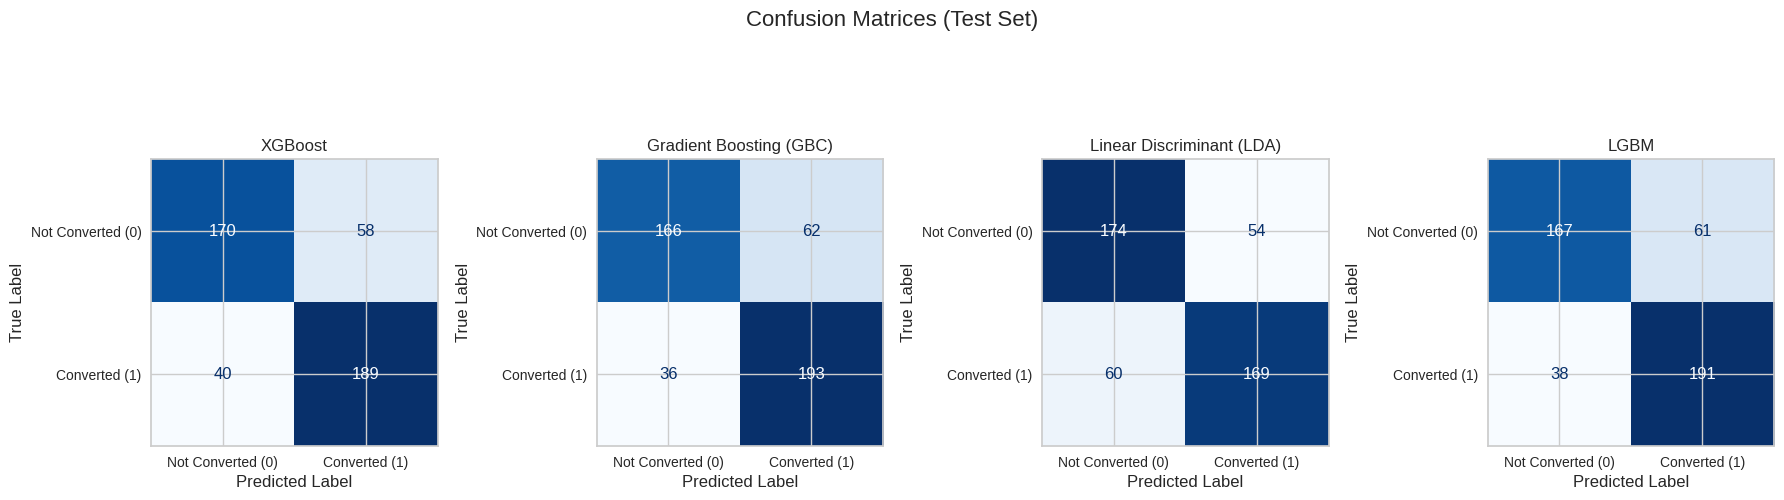

In [ ]:
#confusion matrix code


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions from the best models found in GridSearchCV
xgb_preds = xgb_grid.predict(X_test)
gbc_preds = gbc_grid.predict(X_test)
lda_preds = lda_grid.predict(X_test)
lgbm_preds = lgbm_grid.predict(X_test)
# Setup a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=16, y=1.05)

# Dictionary of predictions to loop through easily
model_predictions = {
    'XGBoost': xgb_preds,
    'Gradient Boosting (GBC)': gbc_preds,
    'Linear Discriminant (LDA)': lda_preds,
    'LGBM': lgbm_preds
}

# Plot each confusion matrix
for ax, (name, y_pred) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    # Create the display object
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Not Converted (0)', 'Converted (1)']
    )

    # Plotting to the specific subplot axis
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}')

    # Adjusting labels for readability
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Save and show the plot
plt.show()


=== Generating Feature Importance & SHAP ===


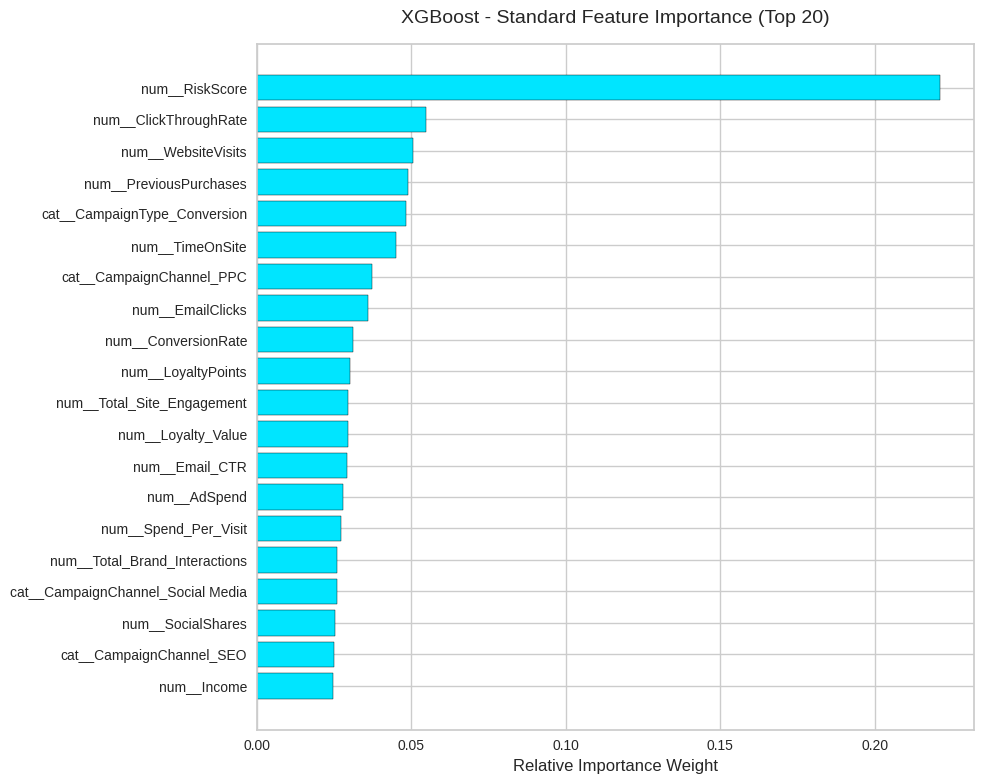


Calculating SHAP values... (this takes a few seconds)


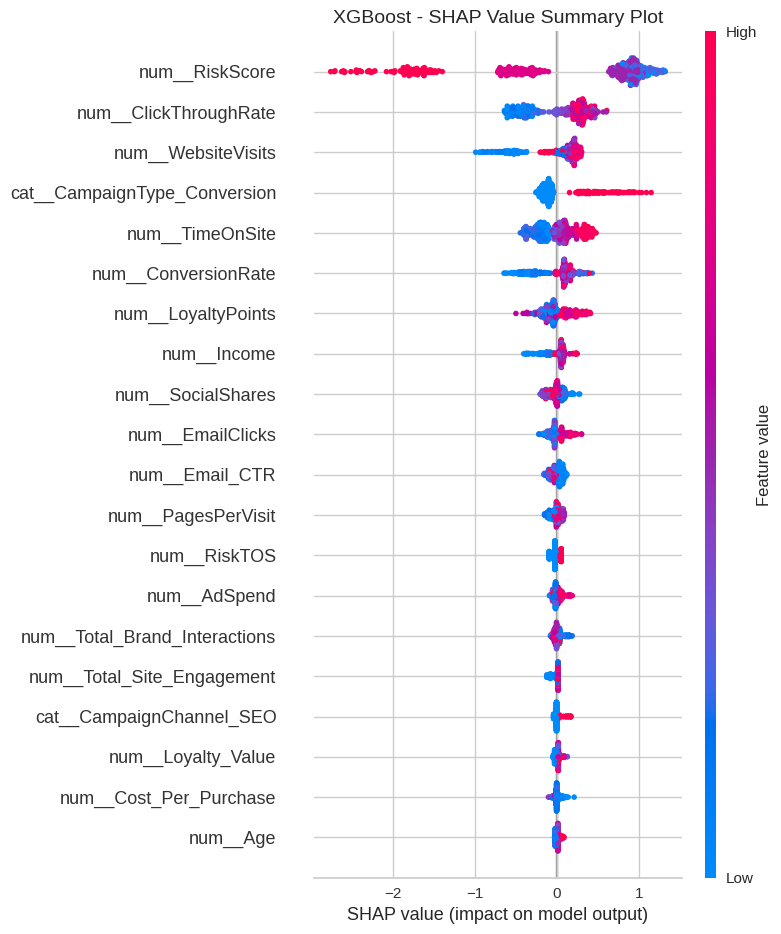

In [ ]:
#shap code


import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\n=== Generating Feature Importance & SHAP ===")

# 1. Extract the trained XGBoost model and Preprocessor from your Pipeline
# USING 'xgb_grid' exactly as it is named in your code
best_xgb = xgb_grid.best_estimator_.named_steps['classifier']
preprocessor = xgb_grid.best_estimator_.named_steps['preprocessor']

# 2. Extract the new feature names (after OneHotEncoding and Scaling)
feature_names = preprocessor.get_feature_names_out()

# 3. Transform the test data (The model and SHAP need the preprocessed numbers)
X_test_transformed = preprocessor.transform(X_test)

# Convert to a dense array if the preprocessor made it a sparse matrix
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Wrap it in a DataFrame so SHAP can use the actual column names
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# =======================================================
# PLOT 1: Standard Feature Importance
# =======================================================
plt.figure(figsize=(10, 8))
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]

# Display the Top 20 features for readability
top_n = min(20, len(feature_names))
top_indices = indices[:top_n]

plt.title("XGBoost - Standard Feature Importance (Top 20)", fontsize=14, pad=15)
plt.barh(range(top_n), importances[top_indices][::-1], color="#00e5ff", edgecolor="black")
plt.yticks(range(top_n), [feature_names[i] for i in top_indices][::-1], fontsize=10)
plt.xlabel("Relative Importance Weight", fontsize=12)
plt.tight_layout()
plt.show()

# =======================================================
# PLOT 2: SHAP Summary Plot
# =======================================================
print("\nCalculating SHAP values... (this takes a few seconds)")
# SHAP needs the exact tree model to calculate paths
explainer = shap.TreeExplainer(best_lgbm)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_df)

# Plot the SHAP summary
plt.figure(figsize=(10, 8))
plt.title("XGBoost - SHAP Value Summary Plot", fontsize=14)
shap.summary_plot(shap_values, X_test_df, show=False)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion'],
      dtype='object')

In [ ]:
df['Email_CTR'] = df['EmailClicks'] / (df['EmailOpens'] + 0.001)
df['Spend_Per_Visit'] = df['AdSpend'] / (df['WebsiteVisits'] + 0.001)
df['Cost_Per_Purchase'] = df['AdSpend'] / (df['PreviousPurchases'] + 1)
df['Total_Site_Engagement'] = df['TimeOnSite'] * df['PagesPerVisit']
df['Loyalty_Value'] = df['LoyaltyPoints'] * df['PreviousPurchases']
df['Total_Brand_Interactions'] = df['WebsiteVisits'] + df['EmailOpens'] + df['EmailClicks'] + df['SocialShares']
df['Is_High_Spender'] = (df['AdSpend'] > df['AdSpend'].median()).astype(int)
df['Zero_Previous_Purchases'] = (df['PreviousPurchases'] == 0).astype(int)
df['RiskEmail']   = (df['EmailOpens'] < 6).astype(int)
df['RiskClicks']  = (df['EmailClicks'] < 3).astype(int)
df['RiskPrev']    = (df['PreviousPurchases'] <= 1).astype(int)
df['RiskLoyalty'] = (df['LoyaltyPoints'] < df['LoyaltyPoints'].quantile(0.25)).astype(int)
df['RiskSpend']   = (df['AdSpend'] <= 5000).astype(int)
df['RiskPPV']     = (df['PagesPerVisit'] <= df['PagesPerVisit'].quantile(0.25)).astype(int)
df['RiskTOS']     = (df['TimeOnSite'] < df['TimeOnSite'].quantile(0.25)).astype(int)
df['RiskScore']   = df[['RiskEmail','RiskClicks','RiskPrev','RiskLoyalty','RiskSpend','RiskPPV','RiskTOS']].sum(axis=1)

In [ ]:
#3 #df + feature en

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import RidgeClassifier  # <--- Imported RidgeClassifier

# 1. Added LightGBM import
from lightgbm import LGBMClassifier

# 2. Added fbeta_score and make_scorer to the imports
from sklearn.metrics import classification_report, accuracy_score, fbeta_score, make_scorer

# 3. Prepare the features and target variable
# Drop 'CustomerID' as it is just an identifier, along with the other specified columns
X = df.drop(columns=[
    'CustomerID','AdvertisingPlatform', 'AdvertisingTool', 'Conversion'
])

y = df['Conversion']

# Identify numeric and categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 4. Create Preprocessing steps (USING MinMaxScaler for Normalization)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# 5. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# ======================================================================
# 6. CREATE CUSTOM SCORER FOR GRIDSEARCH (Beta=0.5 prioritizes precision)
# ======================================================================
f05_scorer = make_scorer(fbeta_score, beta=0.5)


# ----------------------------------------------------------------------
# Model 1: XGBoost (XGB)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training XGBoost ---")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

xgb_param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [3],
    'classifier__learning_rate': [0.1]
}

# Changed scoring to f05_scorer
xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost Params: {xgb_grid.best_params_}")
xgb_preds = xgb_grid.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"XGBoost F0.5 Score: {fbeta_score(y_test, xgb_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 2: Gradient Boosting Classifier (GBC)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Gradient Boosting Classifier (GBC) ---")
gbc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gbc_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

# Changed scoring to f05_scorer
gbc_grid = GridSearchCV(gbc_pipeline, gbc_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
gbc_grid.fit(X_train, y_train)

print(f"Best GBC Params: {gbc_grid.best_params_}")
gbc_preds = gbc_grid.predict(X_test)
print(f"GBC Accuracy: {accuracy_score(y_test, gbc_preds):.4f}")
print(f"GBC F0.5 Score: {fbeta_score(y_test, gbc_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 3: Linear Discriminant Analysis (LDA)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Linear Discriminant Analysis (LDA) ---")
lda_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearDiscriminantAnalysis())
])

lda_param_grid = [
    {'classifier__solver': ['svd']},
    {'classifier__solver': ['lsqr', 'eigen'], 'classifier__shrinkage': ['auto', 0.1, 0.5, 0.9]}
]

# Changed scoring to f05_scorer
lda_grid = GridSearchCV(lda_pipeline, lda_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lda_grid.fit(X_train, y_train)

print(f"Best LDA Params: {lda_grid.best_params_}")
lda_preds = lda_grid.predict(X_test)
print(f"LDA Accuracy: {accuracy_score(y_test, lda_preds):.4f}")
print(f"LDA F0.5 Score: {fbeta_score(y_test, lda_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 4: Ridge Classifier
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Ridge Classifier ---")
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RidgeClassifier(random_state=42))
])

# 'alpha' controls the regularization strength. Larger values specify stronger regularization.
ridge_param_grid = {
    'classifier__alpha': [0.1, 1.0, 10.0, 100.0],
    'classifier__solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

# Changed scoring to f05_scorer
ridge_grid = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge Params: {ridge_grid.best_params_}")
ridge_preds = ridge_grid.predict(X_test)
print(f"Ridge Accuracy: {accuracy_score(y_test, ridge_preds):.4f}")
print(f"Ridge F0.5 Score: {fbeta_score(y_test, ridge_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 5: LightGBM (LGBM)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training LightGBM ---")
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, verbose=-1))
])

lgbm_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

# Changed scoring to f05_scorer
lgbm_grid = GridSearchCV(lgbm_pipeline, lgbm_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lgbm_grid.fit(X_train, y_train)

print(f"Best LGBM Params: {lgbm_grid.best_params_}")
lgbm_preds = lgbm_grid.predict(X_test)
print(f"LGBM Accuracy: {accuracy_score(y_test, lgbm_preds):.4f}")
print(f"LGBM F0.5 Score: {fbeta_score(y_test, lgbm_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Final Evaluation Comparison
# ----------------------------------------------------------------------
print("\n=== Detailed Classification Reports ===")
print("\nXGBoost:\n", classification_report(y_test, xgb_preds))
print("\nGradient Boosting Classifier:\n", classification_report(y_test, gbc_preds))
print("\nLinear Discriminant Analysis:\n", classification_report(y_test, lda_preds))
print("\nRidge Classifier:\n", classification_report(y_test, ridge_preds))
print("\nLightGBM:\n", classification_report(y_test, lgbm_preds))


--- Tuning and Training XGBoost ---
Best XGBoost Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
XGBoost Accuracy: 0.7837
XGBoost F0.5 Score: 0.7785

--- Tuning and Training Gradient Boosting Classifier (GBC) ---
Best GBC Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
GBC Accuracy: 0.7816
GBC F0.5 Score: 0.7780

--- Tuning and Training Linear Discriminant Analysis (LDA) ---
Best LDA Params: {'classifier__shrinkage': 0.5, 'classifier__solver': 'lsqr'}
LDA Accuracy: 0.7687
LDA F0.5 Score: 0.7713

--- Tuning and Training Ridge Classifier ---
Best Ridge Params: {'classifier__alpha': 100.0, 'classifier__solver': 'auto'}
Ridge Accuracy: 0.7666
Ridge F0.5 Score: 0.7696

--- Tuning and Training LightGBM ---
Best LGBM Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
LGBM Accuracy: 0.7880
LGBM F0.5 Score: 0.7776

=== Detailed Clas

In [ ]:
#5tuned model

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import RidgeClassifier
# 1. Added LightGBM
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, accuracy_score, f1_score, fbeta_score, make_scorer

# Assuming df_cleaned is already loaded in your environment
# 2. Prepare the features and target variable
cols_to_drop = [
    'CustomerID', 'Conversion', 'AdvertisingPlatform', 'AdvertisingTool'
]

X = df_cleaned.drop(columns=cols_to_drop, errors='ignore')
y = df_cleaned['Conversion']

# Identify numeric and categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 3. Create Preprocessing steps (USING MinMaxScaler for Normalization)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# 4. Split the data (kept your test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# ======================================================================
# 5. CREATE CUSTOM SCORER (Beta=0.5 prioritizes precision)
# ======================================================================
f05_scorer = make_scorer(fbeta_score, beta=0.5)

# ----------------------------------------------------------------------
# Model 1: XGBoost (XGB) - ADVANCED TUNING
# ----------------------------------------------------------------------
print("\n--- Tuning and Training XGBoost ---")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

xgb_param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 4, 5, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    'classifier__gamma': [0, 0.1, 0.5, 1, 2]
}

xgb_search = RandomizedSearchCV(xgb_pipeline, param_distributions=xgb_param_dist,
                                n_iter=50, cv=5, scoring=f05_scorer, n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)

print(f"Best XGBoost Params: {xgb_search.best_params_}")
xgb_preds = xgb_search.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f} | F1: {f1_score(y_test, xgb_preds):.4f} | F0.5: {fbeta_score(y_test, xgb_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 2: Gradient Boosting Classifier (GBC) - ADVANCED TUNING
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Gradient Boosting Classifier (GBC) ---")
gbc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gbc_param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 4, 5, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0]
}

gbc_search = RandomizedSearchCV(gbc_pipeline, param_distributions=gbc_param_dist,
                                n_iter=40, cv=5, scoring=f05_scorer, n_jobs=-1, random_state=42)
gbc_search.fit(X_train, y_train)

print(f"Best GBC Params: {gbc_search.best_params_}")
gbc_preds = gbc_search.predict(X_test)
print(f"GBC Accuracy: {accuracy_score(y_test, gbc_preds):.4f} | F1: {f1_score(y_test, gbc_preds):.4f} | F0.5: {fbeta_score(y_test, gbc_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 3: Linear Discriminant Analysis (LDA)
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Linear Discriminant Analysis (LDA) ---")
lda_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearDiscriminantAnalysis())
])

lda_param_grid = [
    {'classifier__solver': ['svd']},
    {'classifier__solver': ['lsqr', 'eigen'], 'classifier__shrinkage': ['auto', 0.01, 0.1, 0.5, 0.9]}
]

lda_grid = GridSearchCV(lda_pipeline, lda_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
lda_grid.fit(X_train, y_train)

print(f"Best LDA Params: {lda_grid.best_params_}")
lda_preds = lda_grid.predict(X_test)
print(f"LDA Accuracy: {accuracy_score(y_test, lda_preds):.4f} | F1: {f1_score(y_test, lda_preds):.4f} | F0.5: {fbeta_score(y_test, lda_preds, beta=0.5):.4f}")

# ----------------------------------------------------------------------
# Model 4: Ridge Classifier
# ----------------------------------------------------------------------
print("\n--- Tuning and Training Ridge Classifier ---")
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RidgeClassifier(random_state=42))
])

ridge_param_grid = {
    'classifier__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    'classifier__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg']
}

ridge_grid = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring=f05_scorer, n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge Params: {ridge_grid.best_params_}")
ridge_preds = ridge_grid.predict(X_test)
print(f"Ridge Accuracy: {accuracy_score(y_test, ridge_preds):.4f} | F1: {f1_score(y_test, ridge_preds):.4f} | F0.5: {fbeta_score(y_test, ridge_preds, beta=0.5):.4f}")


# ----------------------------------------------------------------------
# Model 5: LightGBM (LGBM) - ADVANCED TUNING
# ----------------------------------------------------------------------
print("\n--- Tuning and Training LightGBM ---")
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, verbose=-1))
])

# Large grid for RandomizedSearchCV
lgbm_param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 4, 5, 6, 8, -1], # -1 means no limit (let num_leaves control)
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__num_leaves': [20, 31, 50, 70],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(lgbm_pipeline, param_distributions=lgbm_param_dist,
                                 n_iter=50, cv=5, scoring=f05_scorer, n_jobs=-1, random_state=42)
lgbm_search.fit(X_train, y_train)

print(f"Best LGBM Params: {lgbm_search.best_params_}")
lgbm_preds = lgbm_search.predict(X_test)
print(f"LGBM Accuracy: {accuracy_score(y_test, lgbm_preds):.4f} | F1: {f1_score(y_test, lgbm_preds):.4f} | F0.5: {fbeta_score(y_test, lgbm_preds, beta=0.5):.4f}")


# ----------------------------------------------------------------------
# Final Evaluation Comparison
# ----------------------------------------------------------------------
print("\n=== Detailed Classification Reports ===")
print("\nXGBoost:\n", classification_report(y_test, xgb_preds))
print("\nGradient Boosting Classifier:\n", classification_report(y_test, gbc_preds))
print("\nLinear Discriminant Analysis:\n", classification_report(y_test, lda_preds))
print("\nRidge Classifier:\n", classification_report(y_test, ridge_preds))
print("\nLightGBM:\n", classification_report(y_test, lgbm_preds))


--- Tuning and Training XGBoost ---
Best XGBoost Params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 1, 'classifier__colsample_bytree': 0.8}
XGBoost Accuracy: 0.7462 | F1: 0.7511 | F0.5: 0.7434

--- Tuning and Training Gradient Boosting Classifier (GBC) ---
Best GBC Params: {'classifier__subsample': 0.6, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01}
GBC Accuracy: 0.7681 | F1: 0.7716 | F0.5: 0.7656

--- Tuning and Training Linear Discriminant Analysis (LDA) ---
Best LDA Params: {'classifier__shrinkage': 'auto', 'classifier__solver': 'lsqr'}
LDA Accuracy: 0.7462 | F1: 0.7445 | F0.5: 0.7484

--- Tuning and Training Ridge Classifier ---
Best Ridge Params: {'classifier__alpha': 10.0, 'classifier__solver': 'auto'}
Ridge Accuracy: 0.7418 | F1: 0.7424 | F0.5: 0.7424

--- Tuning and Training LightGBM ---
Best LGBM Params: {'classifier__subsam